In [1]:
# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [3]:
path=r"Dataset/Medical_Cybersecurity_Dataset.csv"

In [4]:
df= upload_dataset(path)
df

,Threat Category,IOCs (Indicators of Compromise),Threat Actor,Attack Vector,Geographical Location,Sentiment in Forums,Severity Score,Suggested Defense Mechanism,Risk Level Prediction,Cleaned Threat Description,Keyword Extraction,Named Entities (NER),Topic Modeling Labels,Word Count
0,DDoS,['123.456.78.9'],APT-28,Email,North Korea,0.99,5,Increase Web Security,4,ransomware attack through network vulnerability,"['malware', 'email', 'attachment']","['CompanyY', 'Malware']",Malware,47
1,Malware,"['10.0.0.2', 'infected.exe']",Lazarus Group,Network,USA,0.97,1,Quarantine,4,phishing email with malicious link,"['DDoS', 'website', 'attack']","['Unknown', 'Phishing Service']",Phishing,31
2,Phishing,"['malwarehash123', 'trojan.com']",APT-28,Email,North Korea,0.87,3,Quarantine,2,ransomware attack through network vulnerability,"['phishing', 'corporate', 'scam']","['CompanyY', 'Malware']",Malware,24
3,DDoS,"['192.168.1.1', 'malicious.com']",Lazarus Group,Web,Global,0.64,2,Quarantine,1,phishing email with malicious link,"['DDoS', 'website', 'attack']","['CompanyY', 'Malware']",DDoS,46
4,DDoS,"['malwarehash123', 'trojan.com']",Unknown,Email,Germany,0.57,1,Patch Vulnerability,1,phishing scam targeting corporate accounts,"['DDoS', 'website', 'attack']","['Lazarus Group', 'Network Device']",DDoS,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Ransomware,['123.456.78.9'],Anonymous,Email,Germany,0.76,5,Increase Web Security,2,malware detected in email attachment,"['malware', 'email', 'attachment']","['Lazarus Group', 'Network Device']",Phishing,39
1096,Ransomware,"['malicious.net', 'spam.exe']",Unknown,Email,USA,0.59,4,Monitor for Phishing,3,malware detected in email attachment,"['phishing', 'corporate', 'scam']","['Anonymous', 'Website']",Ransomware,22
1097,Ransomware,"['192.168.1.1', 'malicious.com']",APT-28,Email,North Korea,0.58,3,Quarantine,2,malware detected in email attachment,"['phishing', 'link', 'email']","['Lazarus Group', 'Network Device']",Phishing,23
1098,Ransomware,"['192.168.1.1', 'malicious.com']",APT-28,Web,Russia,0.73,1,Quarantine,5,phishing scam targeting corporate accounts,"['ransomware', 'network', 'vulnerability']","['Anonymous', 'Website']",Phishing,17


In [5]:
def preprocess_data(df, save_path=None, target_cols=None):

    global label_encoders
    label_encoders = {}  # dictionary to hold encoders for each target column

    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)

        # Separate target columns
        target_df = None
        if target_cols:
            existing_targets = [col for col in target_cols if col in df.columns]
            target_df = df[existing_targets].copy()
            df = df.drop(columns=existing_targets)

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target columns
        if target_df is not None:
            for col in target_df.columns:
                df[col] = target_df[col]

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + (target_cols if target_cols else [])]

    # Join processed text columns into one string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Combine with numerical columns if any
    X_numeric = df[non_text_cols].values if non_text_cols else None
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Encode multiple target columns
    Y_dict = {}
    if target_cols:
        for col in target_cols:
            if col in df.columns:
                le = LabelEncoder()
                Y_dict[col] = le.fit_transform(df[col])
                label_encoders[col] = le

    return X, Y_dict

In [12]:
X, Y_dict = preprocess_data(df, save_path="cleaned_data.csv", target_cols=["Threat Category","Severity Score","Suggested Defense Mechanism"])

Preprocessing data and saving to: cleaned_data.csv


In [13]:
labels_vars = {}  # dictionary to hold the labels
label_encoders_original=label_encoders
for i, (col, le) in enumerate(label_encoders.items(), start=1):
    var_name = f"labels{i}"
    labels_vars[var_name] = list(le.classes_)

# Now you can access them like:
labels1 = labels_vars.get("labels1")
labels2 = labels_vars.get("labels2")
labels3 = labels_vars.get("labels3")

print("labels1:", labels1)
print("labels2:", labels2)
print("labels3:", labels3)


metrics_calculator_lb1 = MetricsCalculator(labels1)
metrics_calculator_lb2 = MetricsCalculator(labels2)
metrics_calculator_lb3 = MetricsCalculator(labels3)

labels1: ['DDoS', 'Malware', 'Phishing', 'Ransomware']
labels2: [1, 2, 3, 4, 5]
labels3: ['Increase Web Security', 'Monitor for Phishing', 'Patch Vulnerability', 'Quarantine']


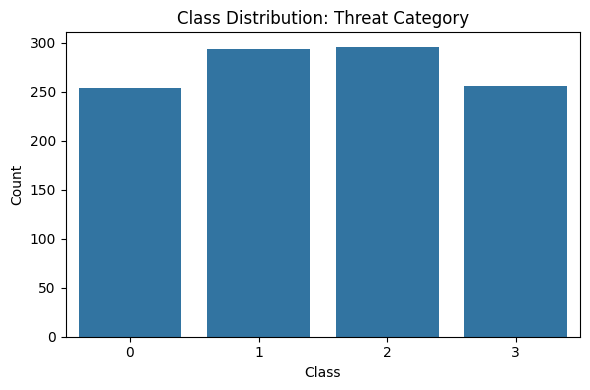

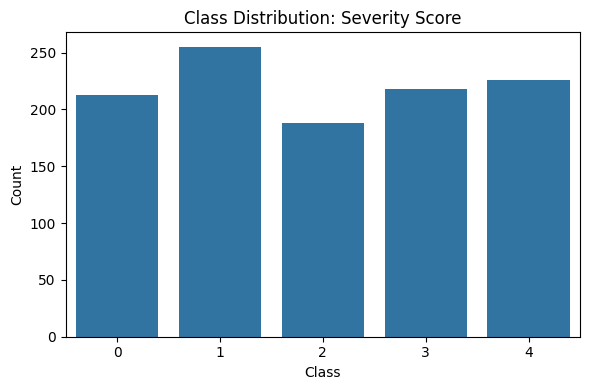

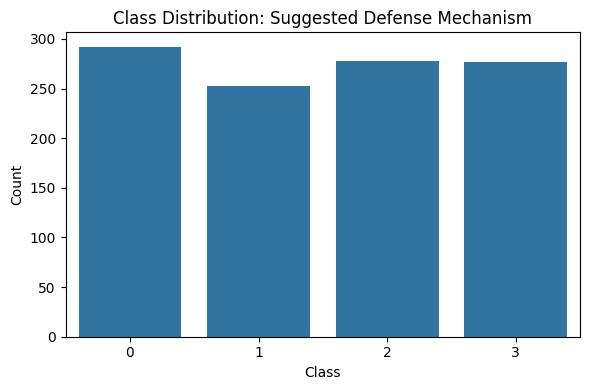

In [14]:
def plot_target_distributions(Y_dict):
    """
    Create count plots for each target column in Y_dict.
    
    Parameters:
        Y_dict (dict): Dictionary where keys are target column names and values are encoded label arrays.
    """
    # Convert to DataFrame for easy plotting
    y_df = pd.DataFrame(Y_dict)

    # Plot each column
    for col in y_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y_df[col])
        plt.title(f'Class Distribution: {col}')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
plot_target_distributions(Y_dict)


In [15]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


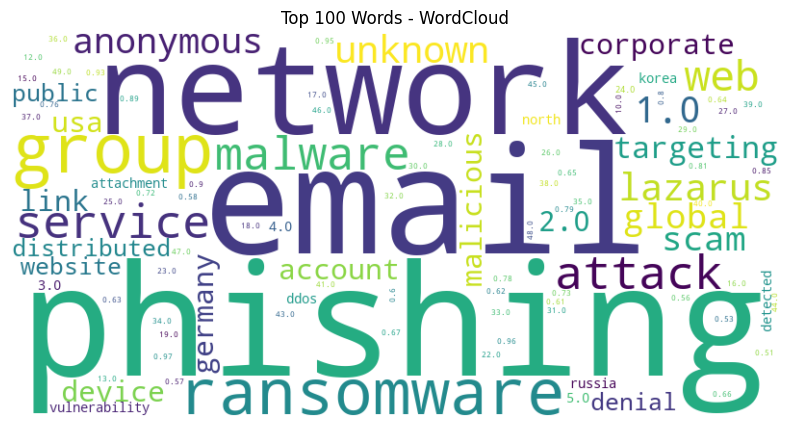

C:\Users\admin\AppData\Local\Temp\ipykernel_10328\1063056502.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


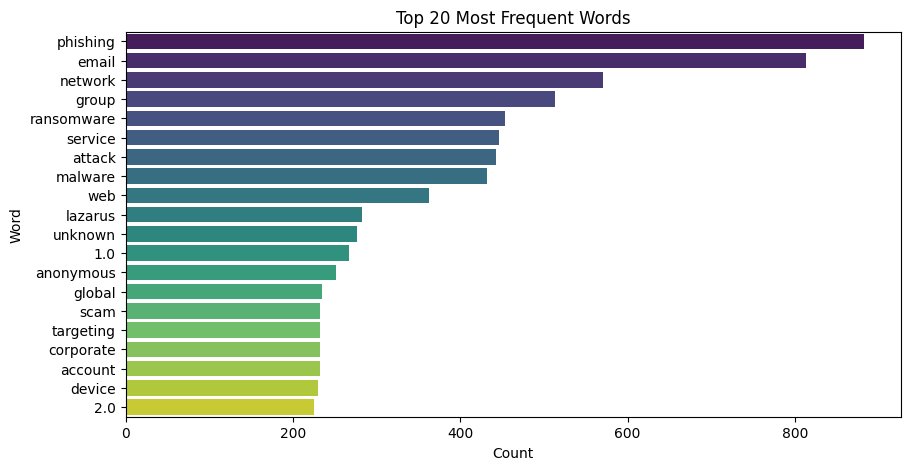

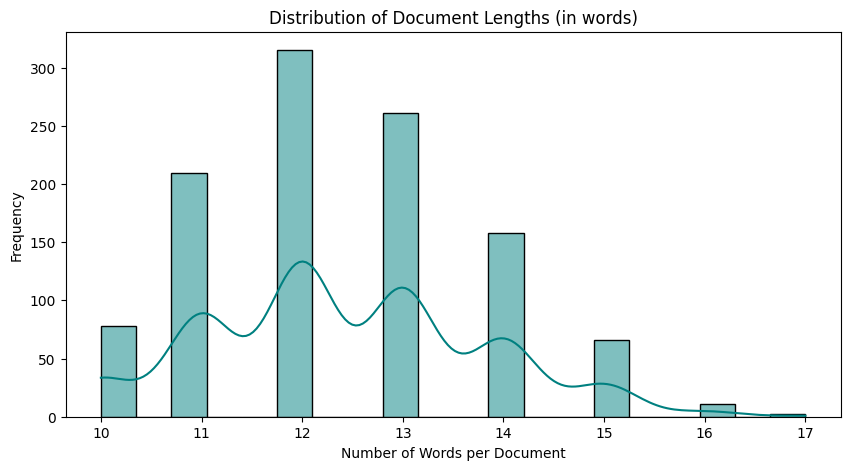

C:\Users\admin\AppData\Local\Temp\ipykernel_10328\1063056502.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")


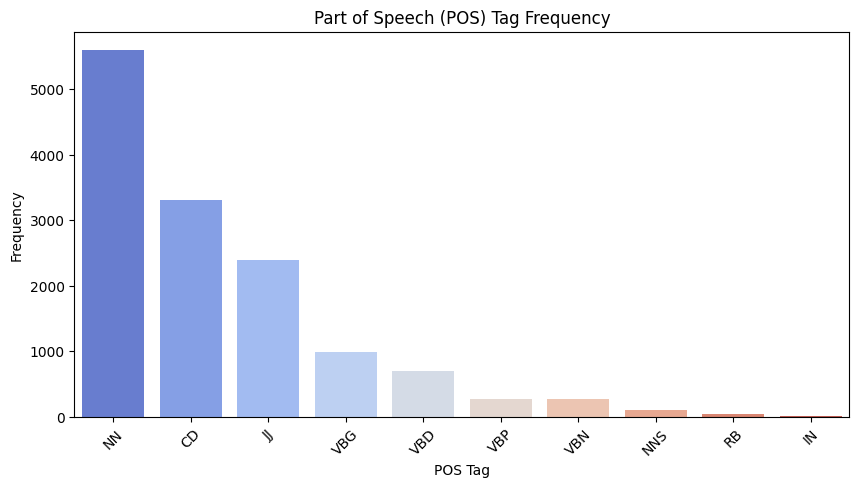

C:\Users\admin\AppData\Local\Temp\ipykernel_10328\1063056502.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")


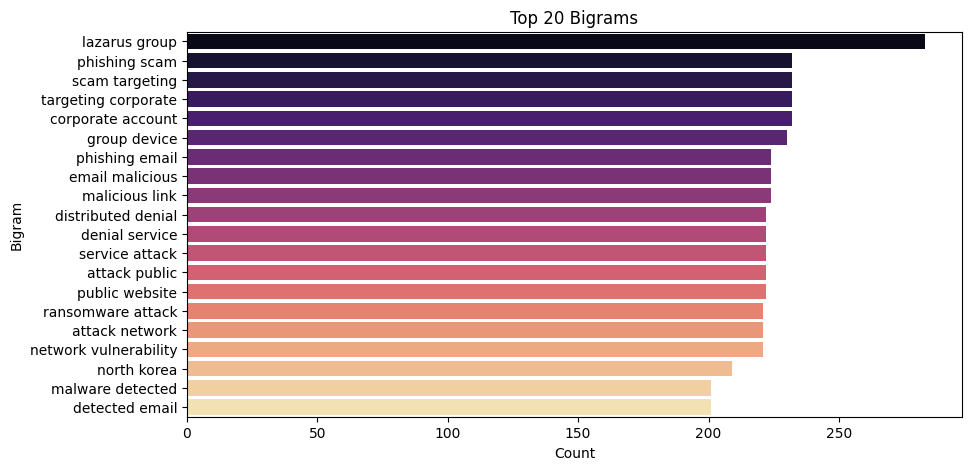

In [18]:
eda_nlp_analysis(X_text=X, num_words=100, top_n_words=20)

In [19]:
from tqdm import tqdm

def deberta_feature_extraction(texts, model_name='microsoft/deberta-base', batch_size=32, pooling='mean'):
    """Extract DeBERTa features from texts with tqdm progress bar."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting DeBERTa embeddings"):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state  # [batch_size, seq_len, hidden_dim]
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        if pooling == 'mean':
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
            sum_mask = input_mask_expanded.sum(dim=1)
            embeddings = sum_embeddings / sum_mask
        elif pooling == 'cls':
            embeddings = token_embeddings[:, 0, :]  # CLS token
        else:
            raise ValueError("Pooling must be 'mean' or 'cls'")

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model


def feature_extraction(X_text, method='DeBERTa_word_embeddings', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'microsoft/deberta-base'  # Lightweight alternative: 'microsoft/deberta-v3-small'

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached DeBERTa features from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing DeBERTa features...")
            X, model = deberta_feature_extraction(X_text, model_name=model_name, pooling='mean')
            os.makedirs(model_dir, exist_ok=True)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Performing DeBERTa feature extraction for testing...")
        X, model = deberta_feature_extraction(X_text, model_name=model_name, pooling='mean')

    return X

In [20]:
features = feature_extraction(X, method='DeBERTa_word_embeddings',is_train=True)

[INFO] Feature extraction method: DeBERTa_word_embeddings, Train mode: True
[INFO] Loading cached DeBERTa features from model\X_DeBERTa_word_embeddings.pkl


In [21]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

features_smoted = {}
labels_smoted = {}

for i, (key, y) in enumerate(Y_dict.items(), start=1):
    X_resampled_initial, y_resampled_initial = resample(features, y, replace=True,n_samples=7000, random_state=42)

    X_resampled, y_resampled = smote.fit_resample(X_resampled_initial, y_resampled_initial)

    features_smoted[f'features{i}'] = X_resampled
    labels_smoted[f'Y{i}'] = y_resampled

    print(f"Balanced '{key}' class: features{i}.shape = {X_resampled.shape}, Y{i}.shape = {y_resampled.shape}")

# Step 3: Build final dictionaries
features_dict = {
    'Threat Category': features_smoted['features1'],
    'Severity Score': features_smoted['features2'],
    'Suggested Defense Mechanism': features_smoted['features3']
}

labels_dict = {
    'Threat Category': labels_smoted['Y1'],
    'Severity Score': labels_smoted['Y2'],
    'Suggested Defense Mechanism': labels_smoted['Y3']
}


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

Balanced 'Threat Category' class: features1.shape = (7568, 768), Y1.shape = (7568,)
Balanced 'Severity Score' class: features2.shape = (8220, 768), Y2.shape = (8220,)
Balanced 'Suggested Defense Mechanism' class: features3.shape = (7248, 768), Y3.shape = (7248,)


In [22]:
from imodels import TaoTreeClassifier, GreedyTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

def train_single_ml_model(Algorithm_prefix, features_dict, Y_dict, algorithm):
    ml_models = {}

    # Mapping of algorithm keys to model classes
    model_mapping = {
        "TAO": TaoTreeClassifier,
        "KNN": KNeighborsClassifier,
        "NBC": GaussianNB,
        "GREEDY_TREE": GreedyTreeClassifier
    }

    if algorithm not in model_mapping:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    # Instantiate classifier class
    ModelClass = model_mapping[algorithm]

    for target_name, y_encoded in Y_dict.items():
        X = features_dict[target_name]
        model_path = f"model/{Algorithm_prefix}_{target_name}_{algorithm}_model.pkl"
        algo_name = f"{Algorithm_prefix} {algorithm} [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )

        if os.path.exists(model_path):
            print(f"Loading existing {algorithm} model for {target_name}...")
            mdl = joblib.load(model_path)
        else:
            print(f"Training {algorithm} for target: {target_name}...")
            mdl = ModelClass()
            mdl.fit(X_train, y_train)
            joblib.dump(mdl, model_path)

        y_pred = mdl.predict(X_test)
        try:
            y_score = mdl.predict_proba(X_test)
        except AttributeError:
            y_score = None

        # Metrics calculation using your existing metric calculators
        if target_name == "Threat Category":
            metrics_calculator_lb1.calculate_metrics(algo_name, y_pred, y_test, y_score)
        elif target_name == "Severity Score":
            metrics_calculator_lb2.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            metrics_calculator_lb3.calculate_metrics(algo_name, y_pred, y_test, y_score)

        ml_models[f"{target_name}_{algorithm}"] = mdl

    return ml_models


Loading existing TAO model for Threat Category...
classes_ [0 1 2 3] preds [2. 3. 2. ... 0. 1. 2.]
RoBERT-WE TAO [Threat Category] Accuracy  : 43.66
RoBERT-WE TAO [Threat Category] Precision : 47.66
RoBERT-WE TAO [Threat Category] Recall    : 43.66
RoBERT-WE TAO [Threat Category] FScore    : 42.61
RoBERT-WE TAO [Threat Category] Classification Report
RoBERT-WE TAO [Threat Category]
              precision    recall  f1-score   support

        DDoS       0.55      0.42      0.48       379
     Malware       0.56      0.22      0.31       378
    Phishing       0.43      0.49      0.46       379
  Ransomware       0.36      0.62      0.46       378

    accuracy                           0.44      1514
   macro avg       0.48      0.44      0.43      1514
weighted avg       0.48      0.44      0.43      1514




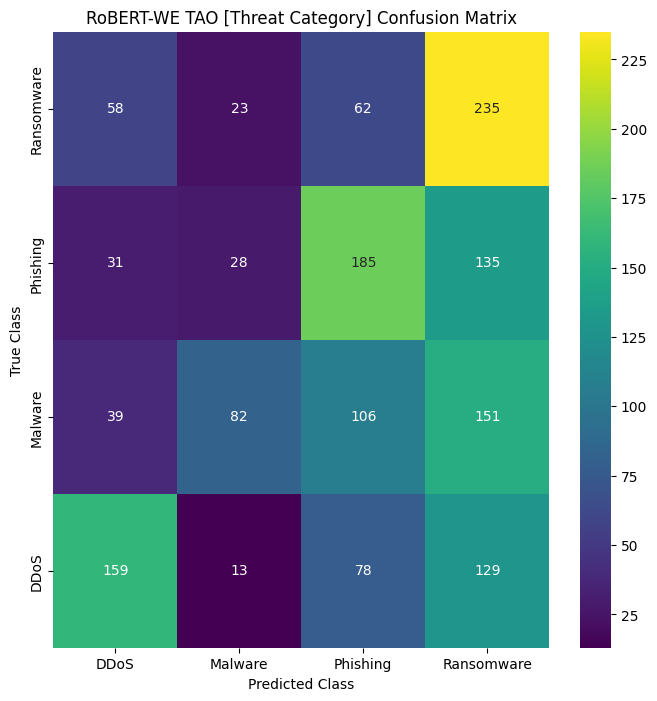

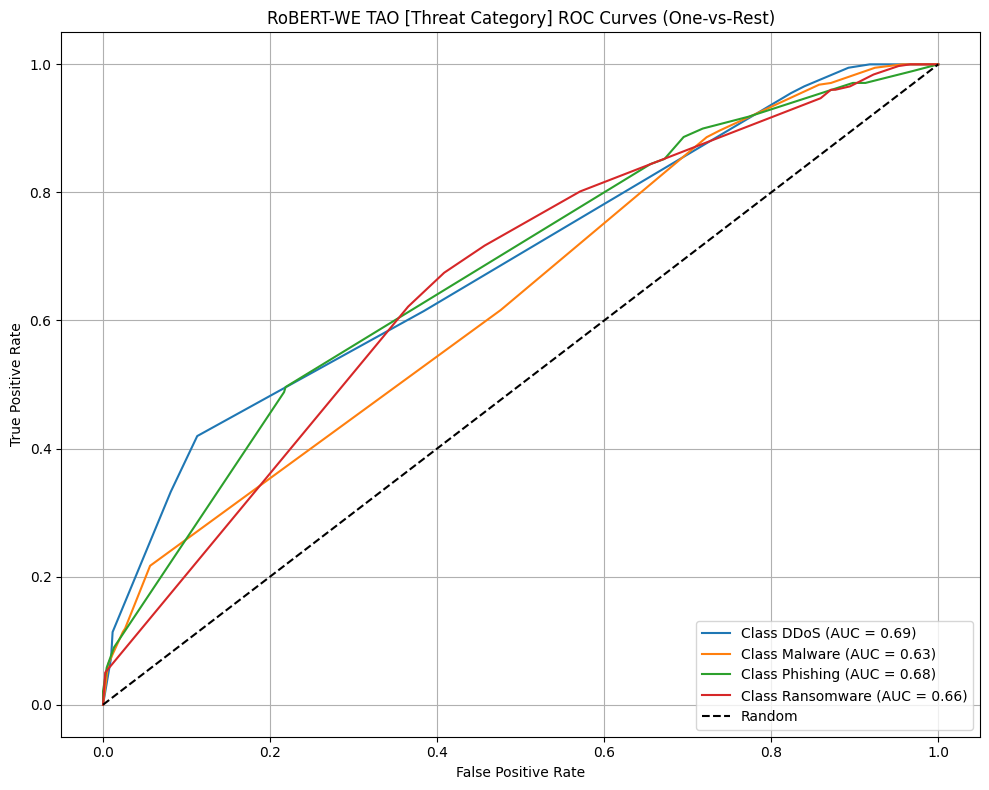

Loading existing TAO model for Severity Score...
classes_ [0 1 2 3 4] preds [0. 0. 0. ... 0. 1. 1.]
RoBERT-WE TAO [Severity Score] Accuracy  : 34.00
RoBERT-WE TAO [Severity Score] Precision : 56.66
RoBERT-WE TAO [Severity Score] Recall    : 34.02
RoBERT-WE TAO [Severity Score] FScore    : 28.84
RoBERT-WE TAO [Severity Score] Classification Report
RoBERT-WE TAO [Severity Score]
              precision    recall  f1-score   support

           1       0.28      0.72      0.40       329
           2       0.30      0.56      0.39       328
           3       0.78      0.29      0.43       329
           4       0.75      0.03      0.05       329
           5       0.72      0.09      0.17       329

    accuracy                           0.34      1644
   macro avg       0.57      0.34      0.29      1644
weighted avg       0.57      0.34      0.29      1644




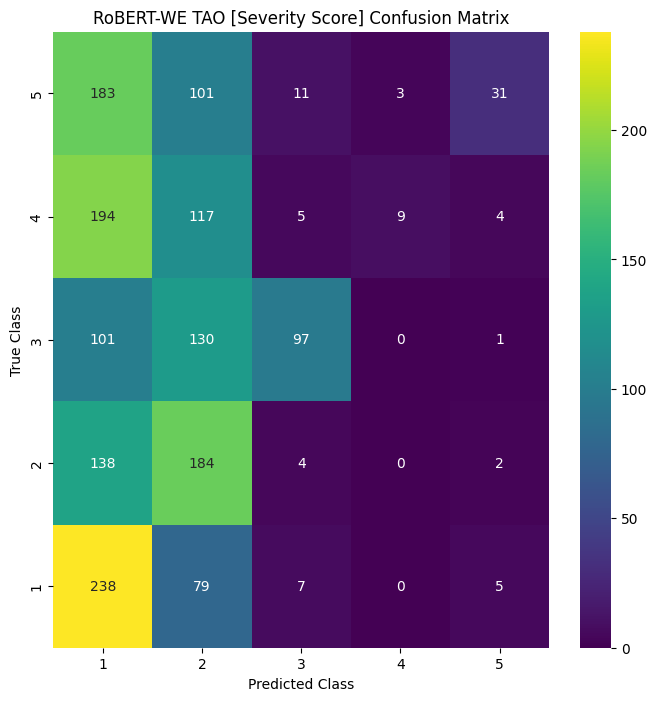

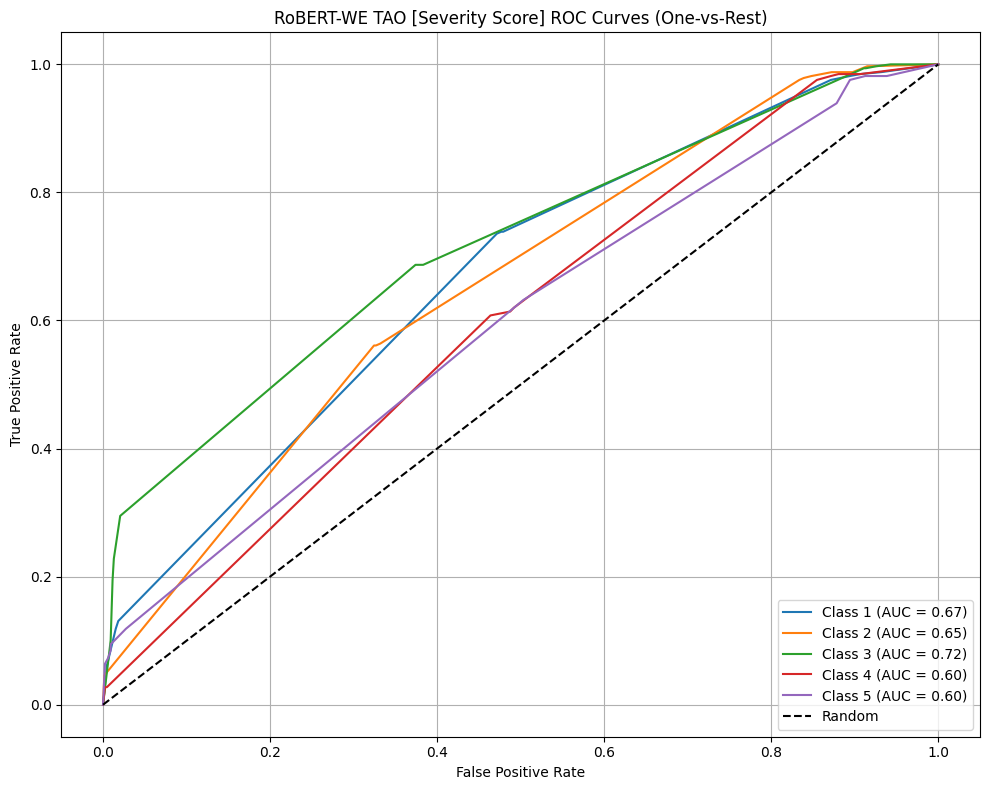

Loading existing TAO model for Suggested Defense Mechanism...
classes_ [0 1 2 3] preds [1. 0. 1. ... 2. 1. 1.]
RoBERT-WE TAO [Suggested Defense Mechanism] Accuracy  : 41.45
RoBERT-WE TAO [Suggested Defense Mechanism] Precision : 42.37
RoBERT-WE TAO [Suggested Defense Mechanism] Recall    : 41.45
RoBERT-WE TAO [Suggested Defense Mechanism] FScore    : 40.21
RoBERT-WE TAO [Suggested Defense Mechanism] Classification Report
RoBERT-WE TAO [Suggested Defense Mechanism]
                       precision    recall  f1-score   support

Increase Web Security       0.43      0.46      0.44       363
 Monitor for Phishing       0.40      0.62      0.49       362
  Patch Vulnerability       0.39      0.34      0.36       363
           Quarantine       0.48      0.24      0.32       362

             accuracy                           0.41      1450
            macro avg       0.42      0.41      0.40      1450
         weighted avg       0.42      0.41      0.40      1450




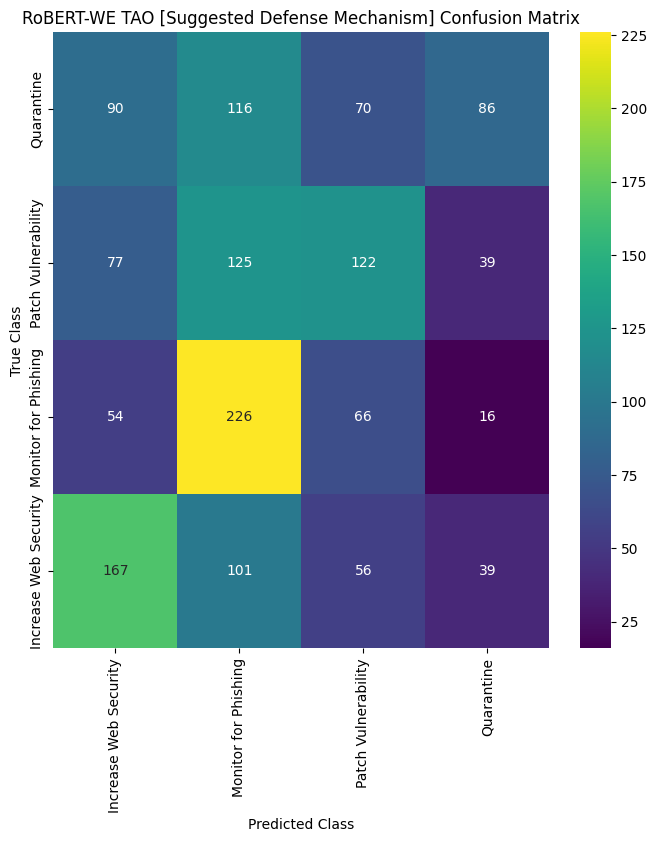

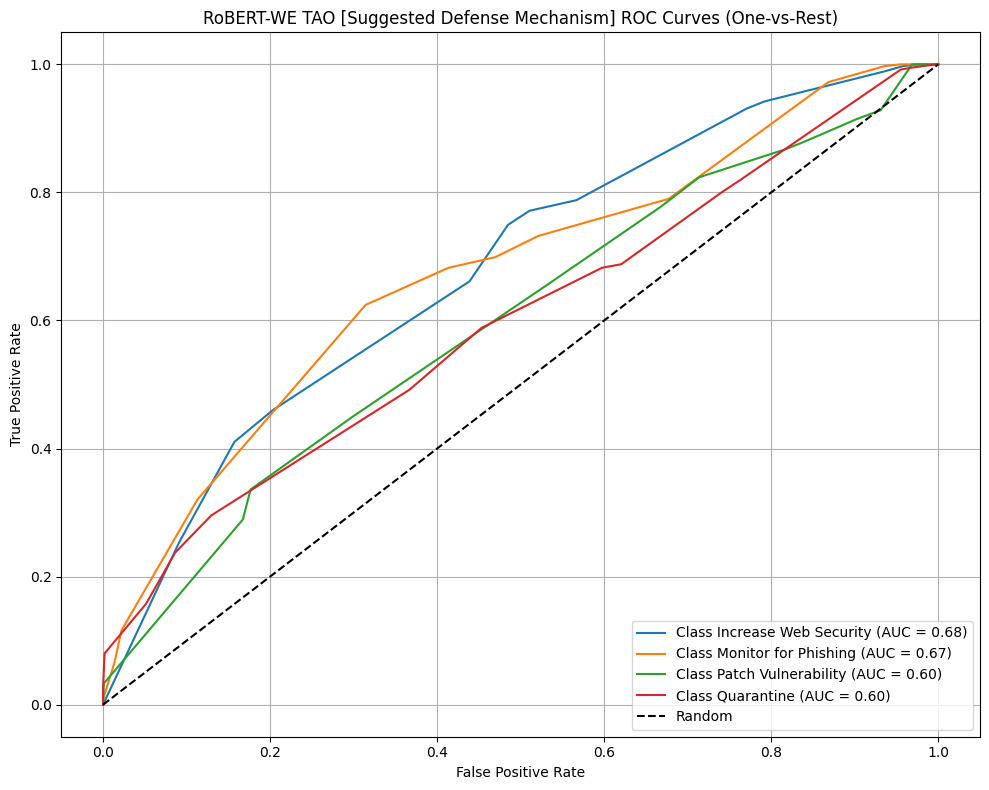

In [23]:
import warnings
warnings.filterwarnings("ignore")

models = train_single_ml_model("RoBERT-WE", features_dict, labels_dict, "TAO")

Loading existing KNN model for Threat Category...
RoBERT-WE KNN [Threat Category] Accuracy  : 91.94
RoBERT-WE KNN [Threat Category] Precision : 91.95
RoBERT-WE KNN [Threat Category] Recall    : 91.94
RoBERT-WE KNN [Threat Category] FScore    : 91.91
RoBERT-WE KNN [Threat Category] Classification Report
RoBERT-WE KNN [Threat Category]
              precision    recall  f1-score   support

        DDoS       0.93      0.94      0.94       379
     Malware       0.92      0.90      0.91       378
    Phishing       0.91      0.87      0.89       379
  Ransomware       0.91      0.96      0.94       378

    accuracy                           0.92      1514
   macro avg       0.92      0.92      0.92      1514
weighted avg       0.92      0.92      0.92      1514




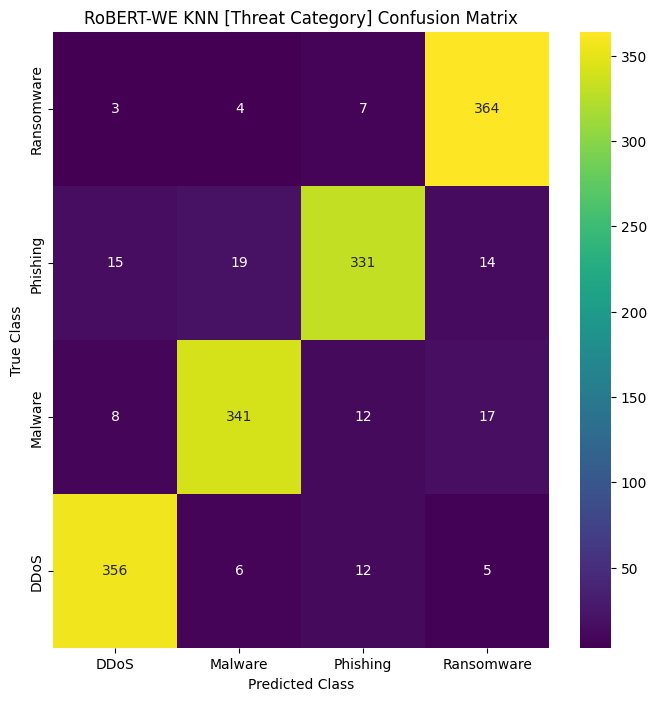

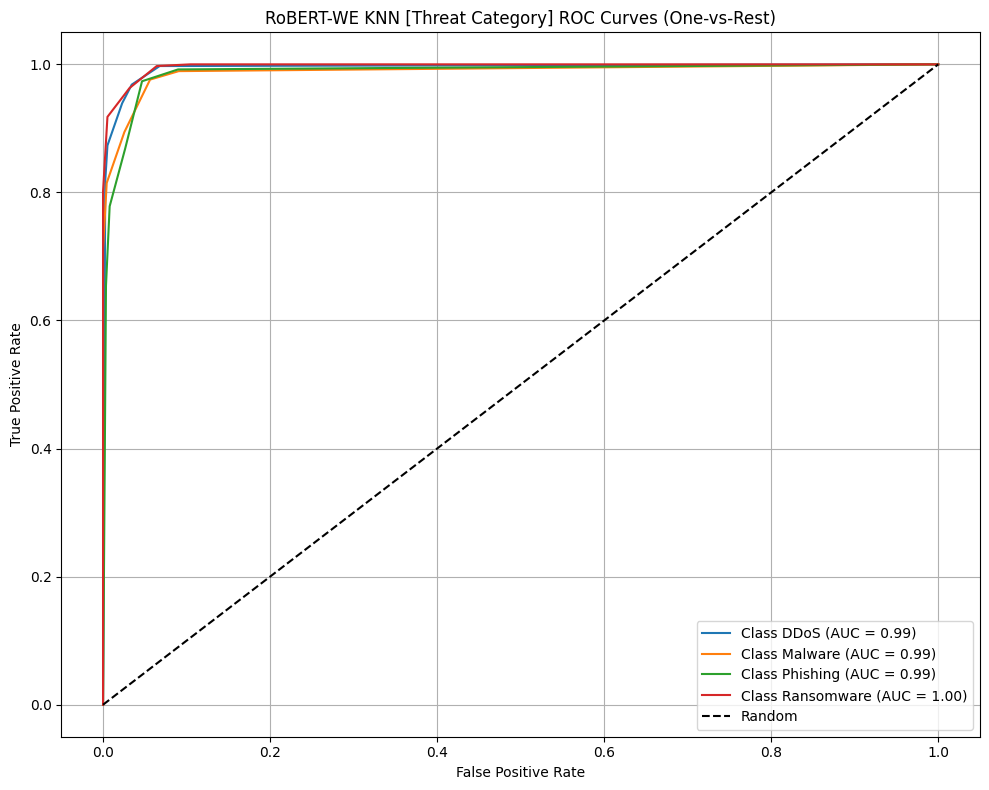

Loading existing KNN model for Severity Score...
RoBERT-WE KNN [Severity Score] Accuracy  : 95.50
RoBERT-WE KNN [Severity Score] Precision : 95.52
RoBERT-WE KNN [Severity Score] Recall    : 95.50
RoBERT-WE KNN [Severity Score] FScore    : 95.50
RoBERT-WE KNN [Severity Score] Classification Report
RoBERT-WE KNN [Severity Score]
              precision    recall  f1-score   support

           1       0.98      0.96      0.97       329
           2       0.92      0.95      0.94       328
           3       0.97      0.97      0.97       329
           4       0.95      0.93      0.94       329
           5       0.96      0.96      0.96       329

    accuracy                           0.95      1644
   macro avg       0.96      0.95      0.96      1644
weighted avg       0.96      0.95      0.96      1644




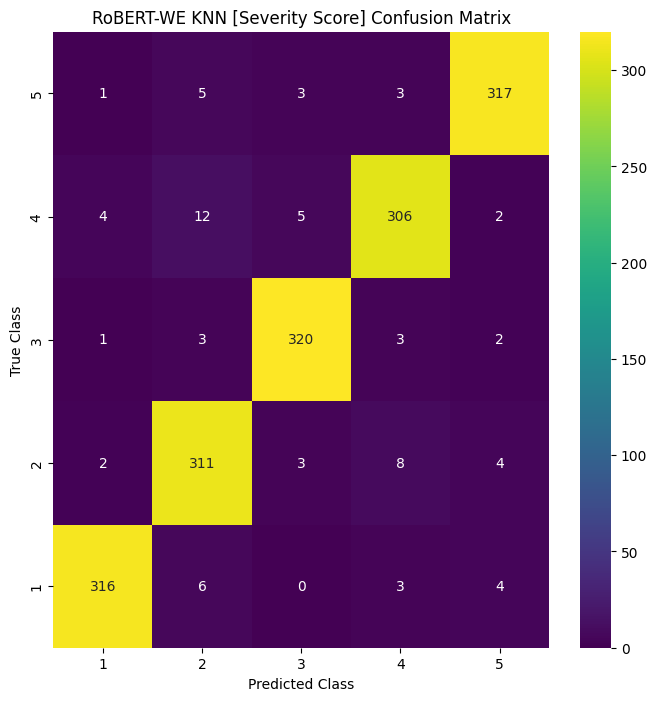

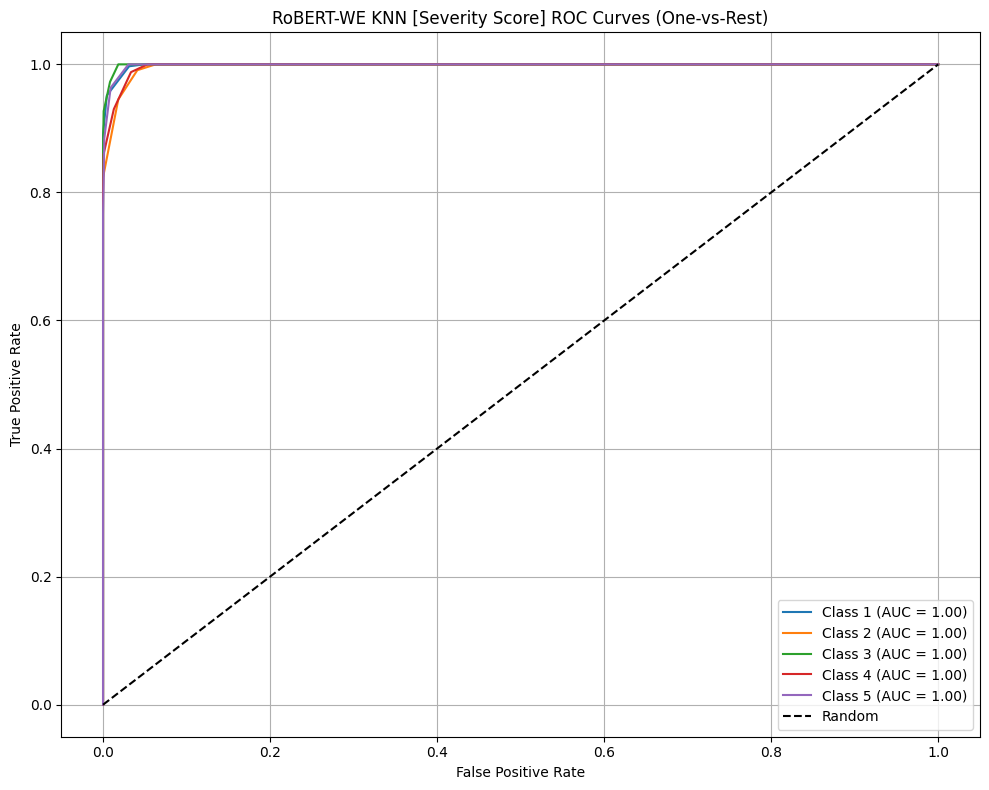

Loading existing KNN model for Suggested Defense Mechanism...
RoBERT-WE KNN [Suggested Defense Mechanism] Accuracy  : 91.38
RoBERT-WE KNN [Suggested Defense Mechanism] Precision : 91.45
RoBERT-WE KNN [Suggested Defense Mechanism] Recall    : 91.38
RoBERT-WE KNN [Suggested Defense Mechanism] FScore    : 91.40
RoBERT-WE KNN [Suggested Defense Mechanism] Classification Report
RoBERT-WE KNN [Suggested Defense Mechanism]
                       precision    recall  f1-score   support

Increase Web Security       0.88      0.91      0.90       363
 Monitor for Phishing       0.95      0.92      0.94       362
  Patch Vulnerability       0.92      0.90      0.91       363
           Quarantine       0.91      0.93      0.92       362

             accuracy                           0.91      1450
            macro avg       0.91      0.91      0.91      1450
         weighted avg       0.91      0.91      0.91      1450




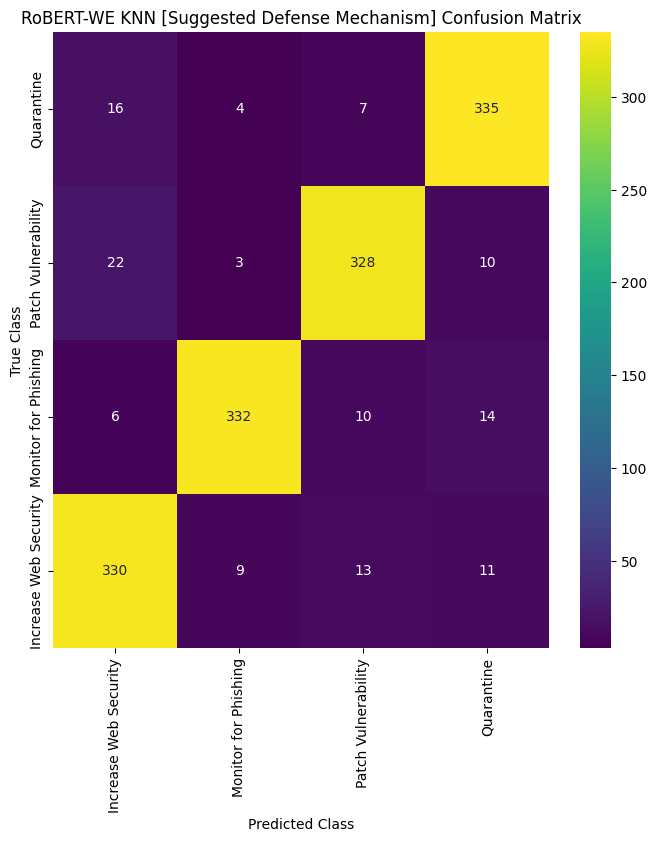

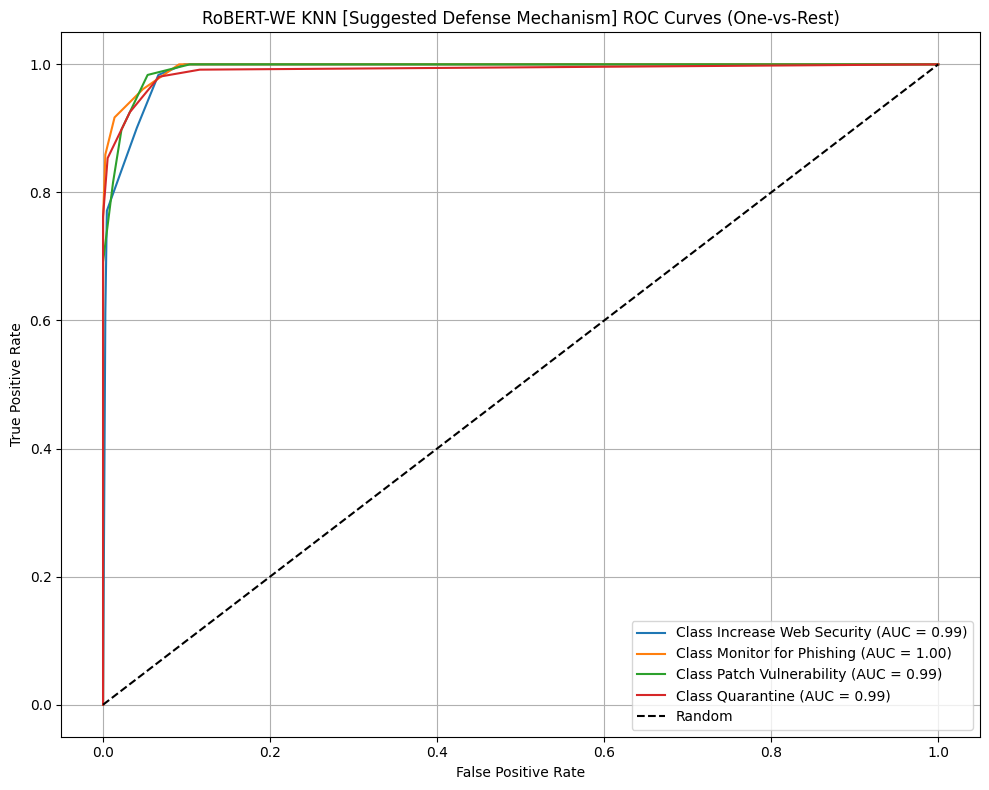

In [16]:
models = train_single_ml_model("RoBERT-WE", features_dict, labels_dict, "KNN")

Loading existing NBC model for Threat Category...
RoBERT-WE NBC [Threat Category] Accuracy  : 34.94
RoBERT-WE NBC [Threat Category] Precision : 34.97
RoBERT-WE NBC [Threat Category] Recall    : 34.94
RoBERT-WE NBC [Threat Category] FScore    : 34.90
RoBERT-WE NBC [Threat Category] Classification Report
RoBERT-WE NBC [Threat Category]
              precision    recall  f1-score   support

        DDoS       0.36      0.34      0.35       379
     Malware       0.36      0.33      0.34       378
    Phishing       0.36      0.40      0.38       379
  Ransomware       0.33      0.34      0.33       378

    accuracy                           0.35      1514
   macro avg       0.35      0.35      0.35      1514
weighted avg       0.35      0.35      0.35      1514




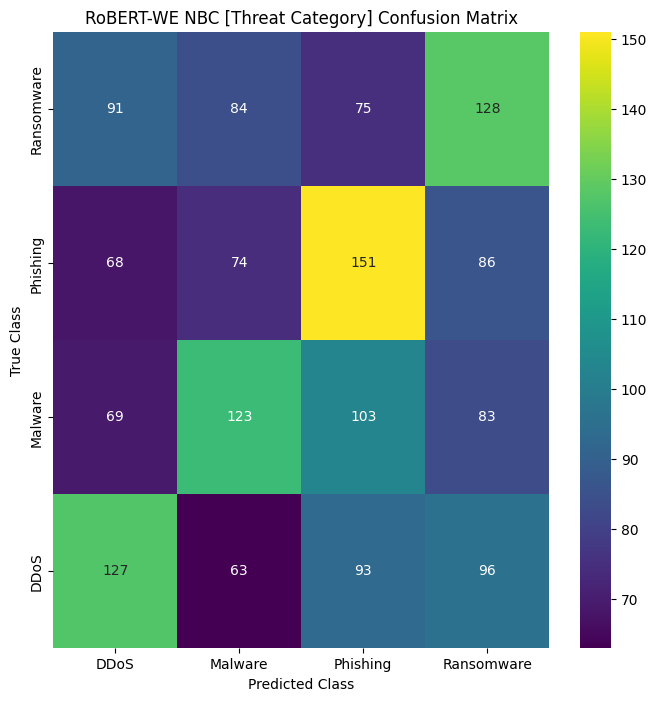

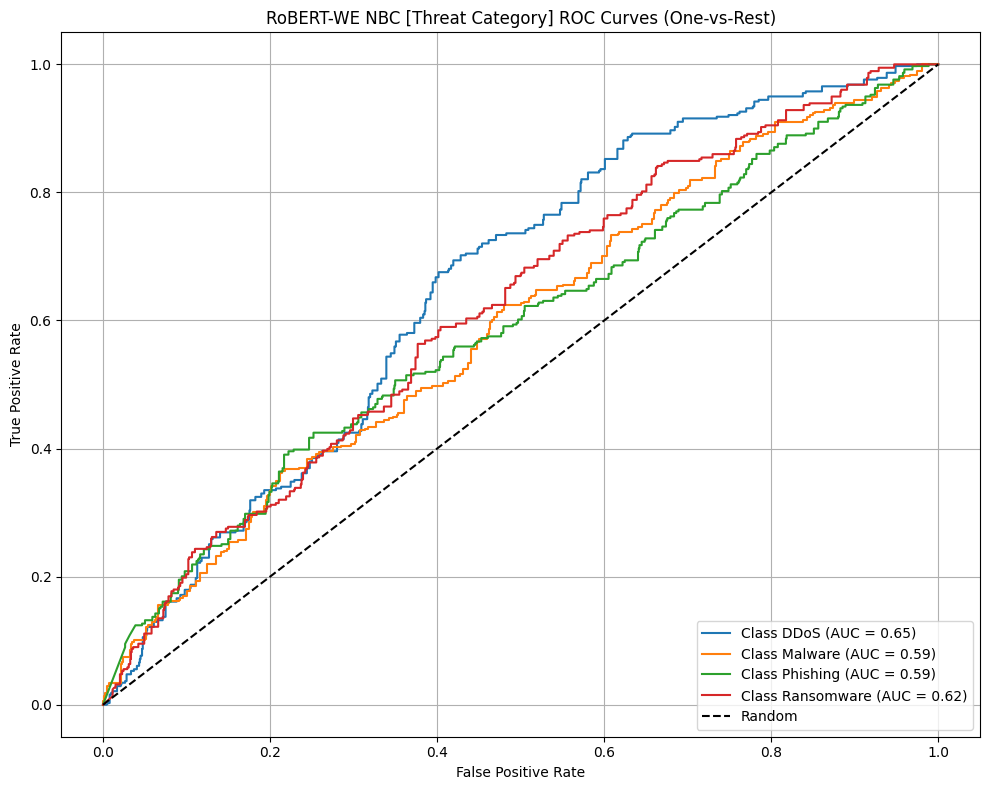

Loading existing NBC model for Severity Score...
RoBERT-WE NBC [Severity Score] Accuracy  : 34.31
RoBERT-WE NBC [Severity Score] Precision : 34.41
RoBERT-WE NBC [Severity Score] Recall    : 34.30
RoBERT-WE NBC [Severity Score] FScore    : 34.07
RoBERT-WE NBC [Severity Score] Classification Report
RoBERT-WE NBC [Severity Score]
              precision    recall  f1-score   support

           1       0.31      0.29      0.30       329
           2       0.30      0.25      0.28       328
           3       0.33      0.45      0.38       329
           4       0.41      0.34      0.37       329
           5       0.36      0.38      0.37       329

    accuracy                           0.34      1644
   macro avg       0.34      0.34      0.34      1644
weighted avg       0.34      0.34      0.34      1644




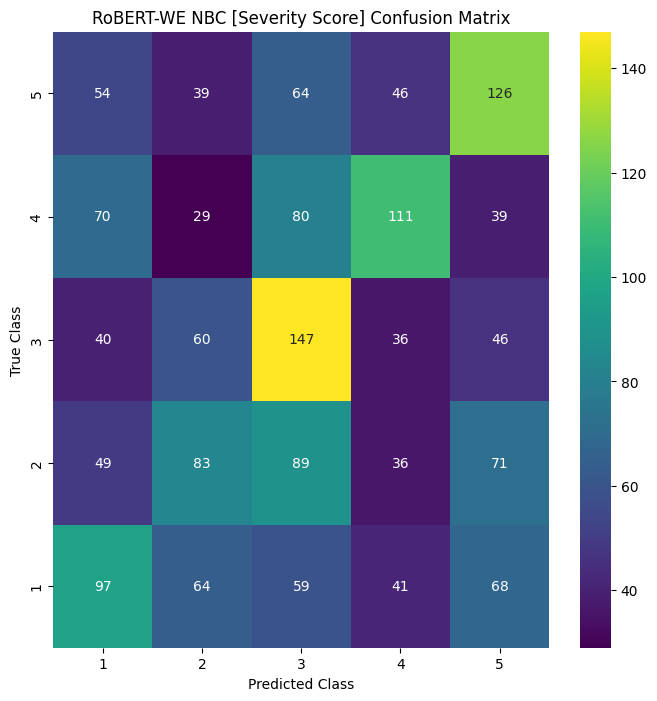

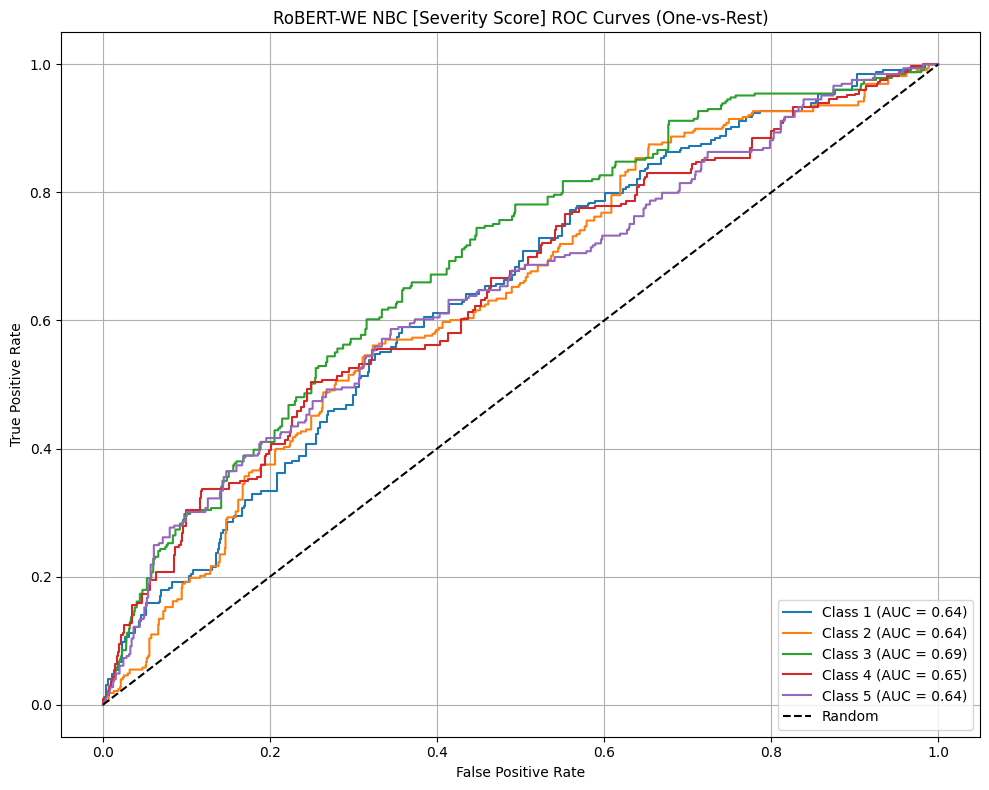

Loading existing NBC model for Suggested Defense Mechanism...
RoBERT-WE NBC [Suggested Defense Mechanism] Accuracy  : 38.07
RoBERT-WE NBC [Suggested Defense Mechanism] Precision : 38.83
RoBERT-WE NBC [Suggested Defense Mechanism] Recall    : 38.07
RoBERT-WE NBC [Suggested Defense Mechanism] FScore    : 38.20
RoBERT-WE NBC [Suggested Defense Mechanism] Classification Report
RoBERT-WE NBC [Suggested Defense Mechanism]
                       precision    recall  f1-score   support

Increase Web Security       0.49      0.39      0.44       363
 Monitor for Phishing       0.36      0.43      0.39       362
  Patch Vulnerability       0.38      0.36      0.36       363
           Quarantine       0.33      0.35      0.34       362

             accuracy                           0.38      1450
            macro avg       0.39      0.38      0.38      1450
         weighted avg       0.39      0.38      0.38      1450




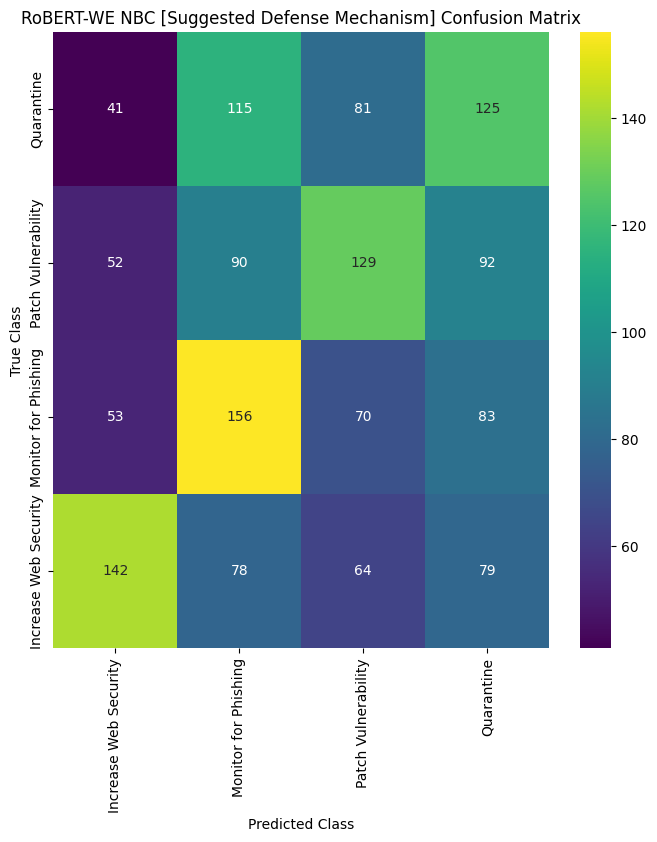

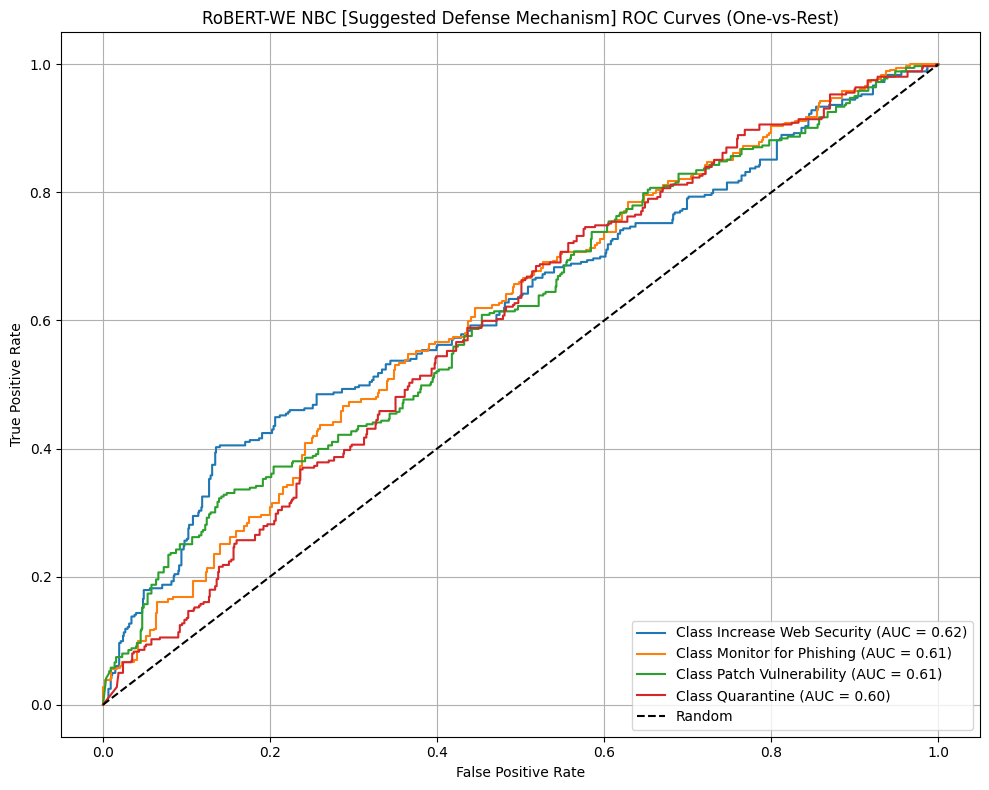

In [24]:
models = train_single_ml_model("RoBERT-WE", features_dict, labels_dict, "NBC")

Loading existing GREEDY_TREE model for Threat Category...
RoBERT-WE GREEDY_TREE [Threat Category] Accuracy  : 99.47
RoBERT-WE GREEDY_TREE [Threat Category] Precision : 99.47
RoBERT-WE GREEDY_TREE [Threat Category] Recall    : 99.47
RoBERT-WE GREEDY_TREE [Threat Category] FScore    : 99.47
RoBERT-WE GREEDY_TREE [Threat Category] Classification Report
RoBERT-WE GREEDY_TREE [Threat Category]
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00       379
     Malware       0.99      0.99      0.99       378
    Phishing       0.99      0.99      0.99       379
  Ransomware       1.00      1.00      1.00       378

    accuracy                           0.99      1514
   macro avg       0.99      0.99      0.99      1514
weighted avg       0.99      0.99      0.99      1514




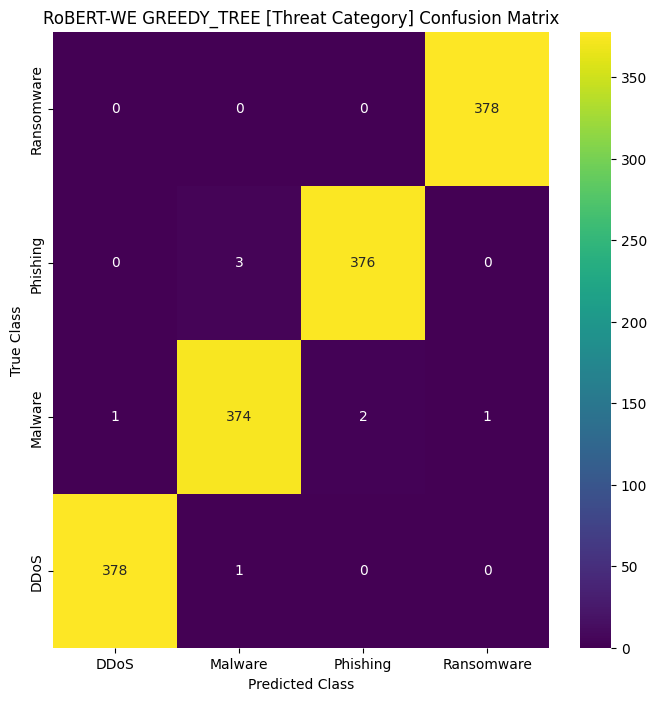

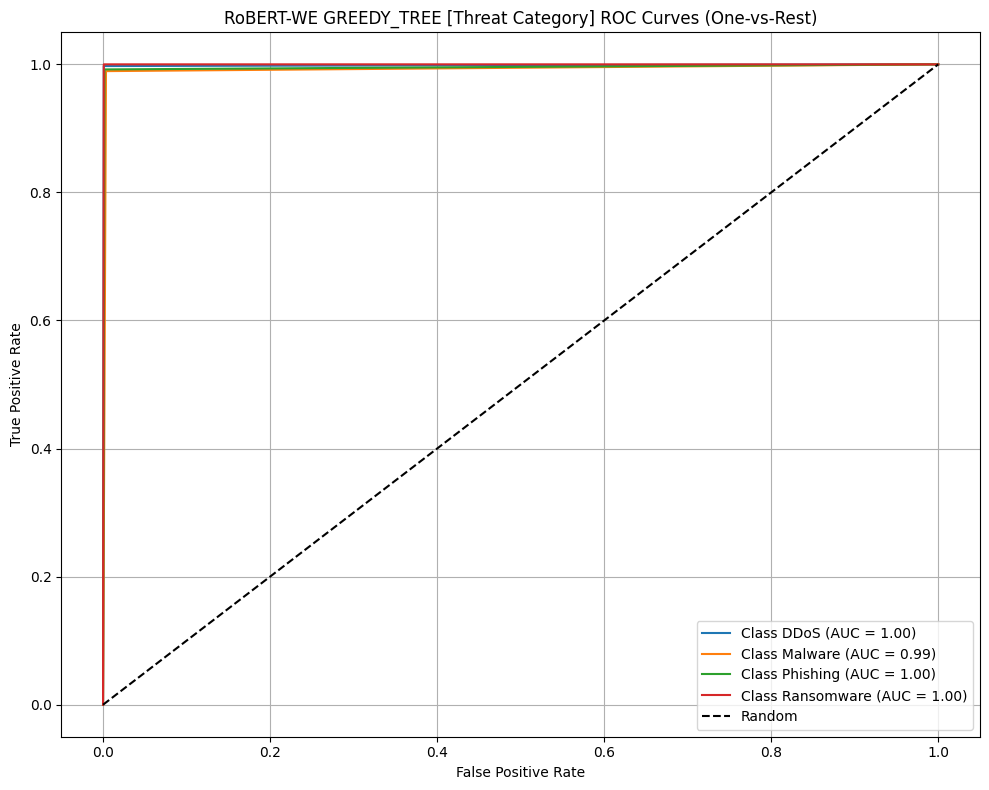

Loading existing GREEDY_TREE model for Severity Score...
RoBERT-WE GREEDY_TREE [Severity Score] Accuracy  : 99.57
RoBERT-WE GREEDY_TREE [Severity Score] Precision : 99.58
RoBERT-WE GREEDY_TREE [Severity Score] Recall    : 99.57
RoBERT-WE GREEDY_TREE [Severity Score] FScore    : 99.57
RoBERT-WE GREEDY_TREE [Severity Score] Classification Report
RoBERT-WE GREEDY_TREE [Severity Score]
              precision    recall  f1-score   support

           1       0.99      1.00      1.00       329
           2       1.00      1.00      1.00       328
           3       1.00      0.99      0.99       329
           4       1.00      1.00      1.00       329
           5       0.99      0.99      0.99       329

    accuracy                           1.00      1644
   macro avg       1.00      1.00      1.00      1644
weighted avg       1.00      1.00      1.00      1644




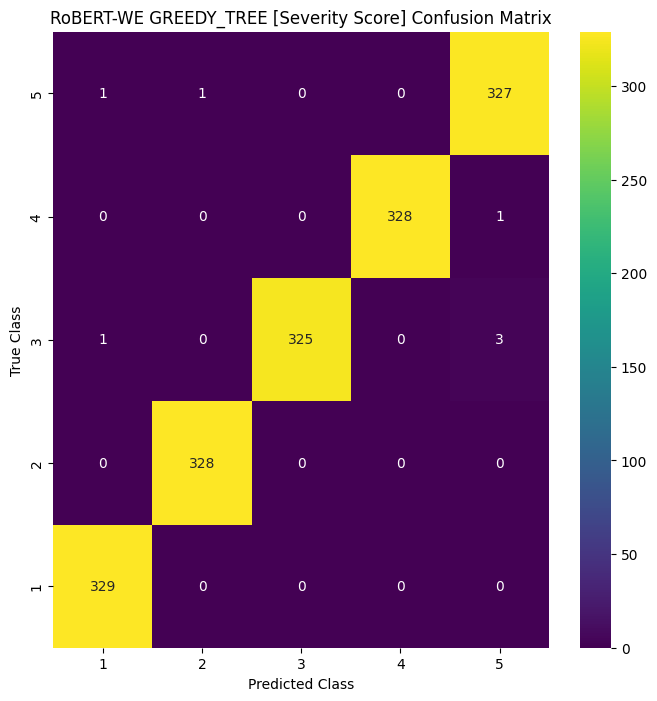

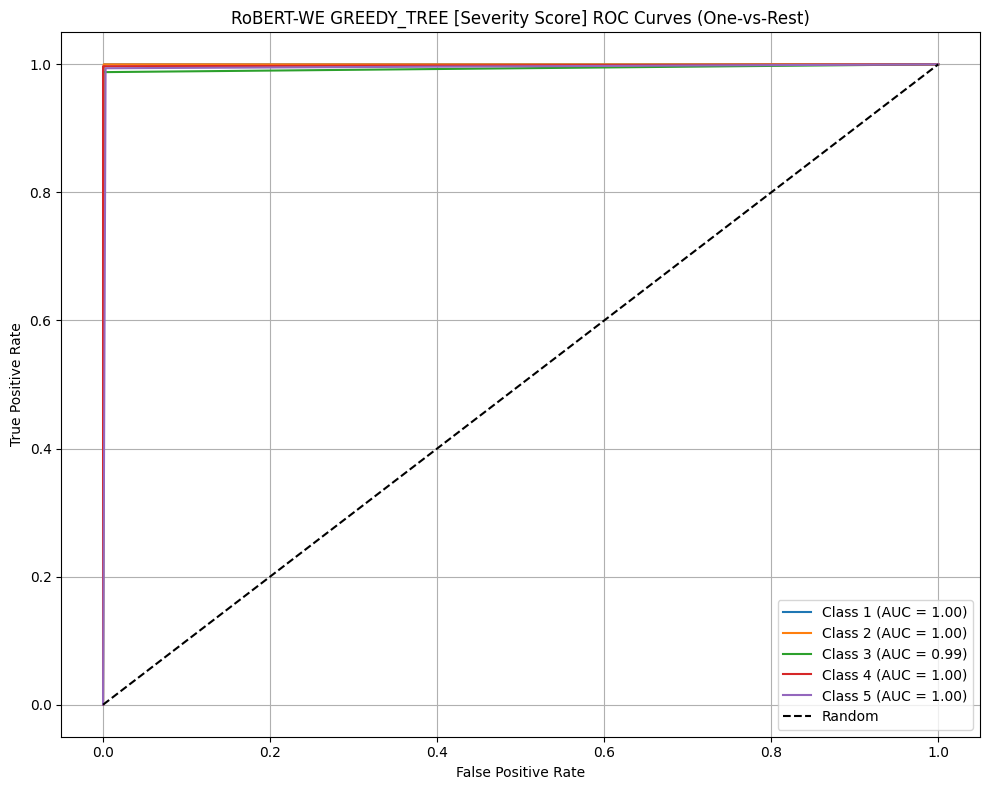

Loading existing GREEDY_TREE model for Suggested Defense Mechanism...
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism] Accuracy  : 99.86
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism] Precision : 99.86
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism] Recall    : 99.86
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism] FScore    : 99.86
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism] Classification Report
RoBERT-WE GREEDY_TREE [Suggested Defense Mechanism]
                       precision    recall  f1-score   support

Increase Web Security       1.00      1.00      1.00       363
 Monitor for Phishing       1.00      1.00      1.00       362
  Patch Vulnerability       1.00      1.00      1.00       363
           Quarantine       1.00      0.99      1.00       362

             accuracy                           1.00      1450
            macro avg       1.00      1.00      1.00      1450
         weighted avg       1.00      1.00      1.00      1450




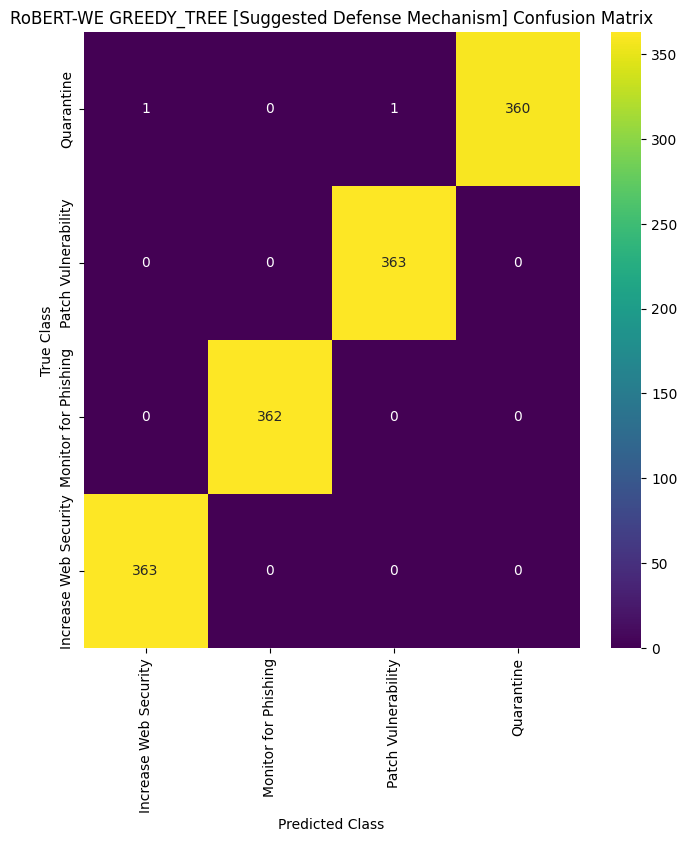

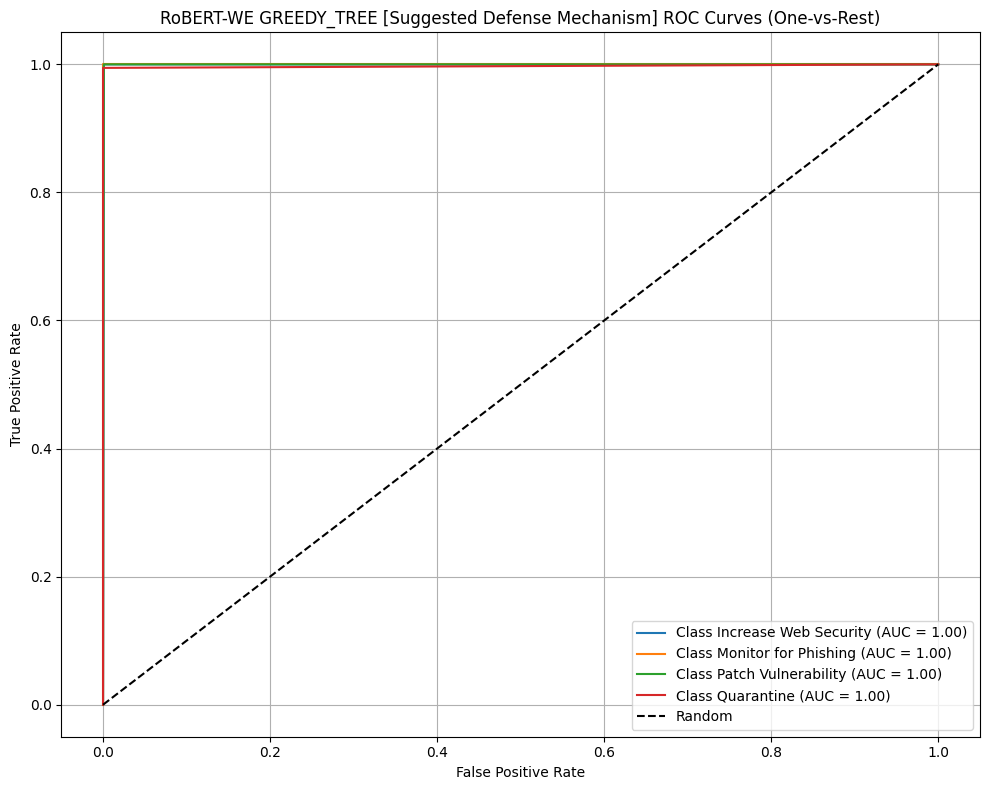

In [25]:
Proposed_Model = train_single_ml_model("RoBERT-WE", features_dict, labels_dict, "GREEDY_TREE")

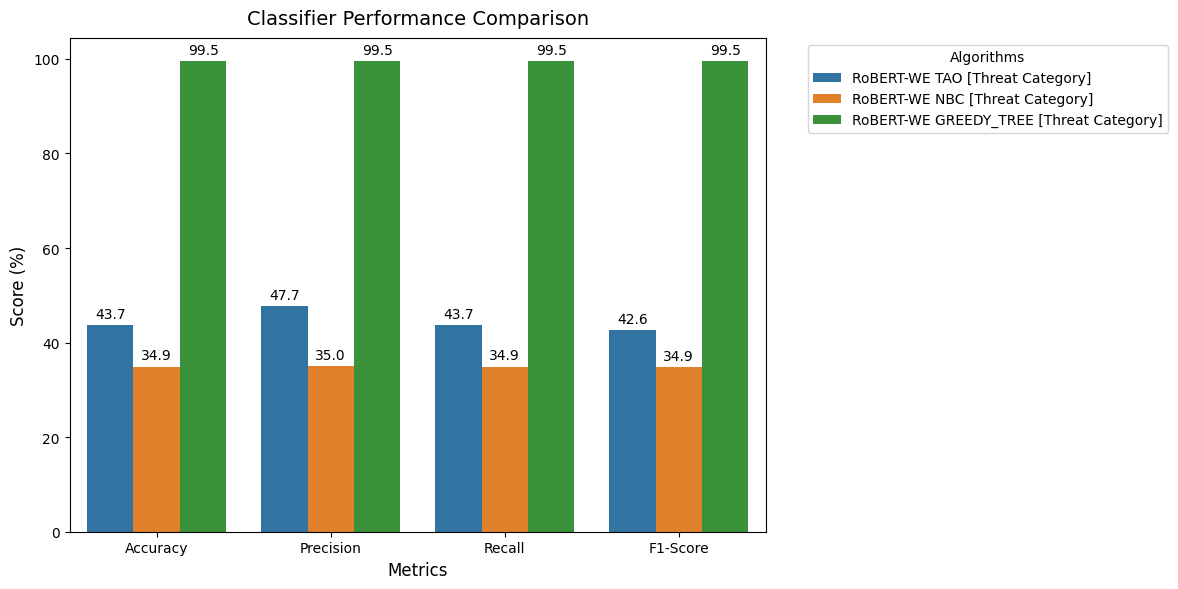

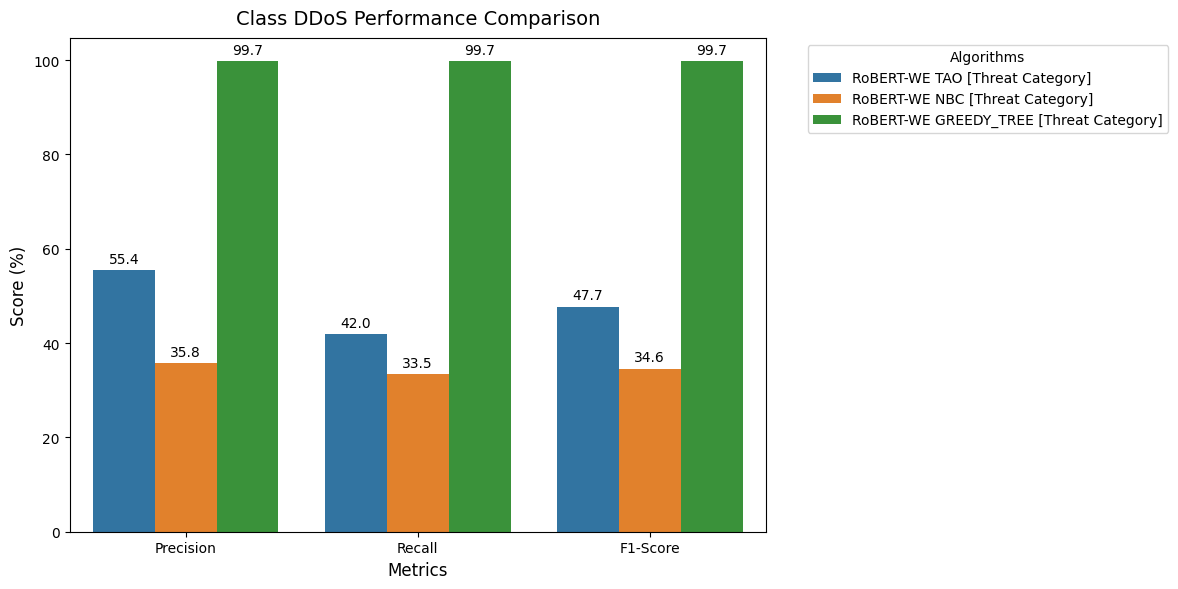

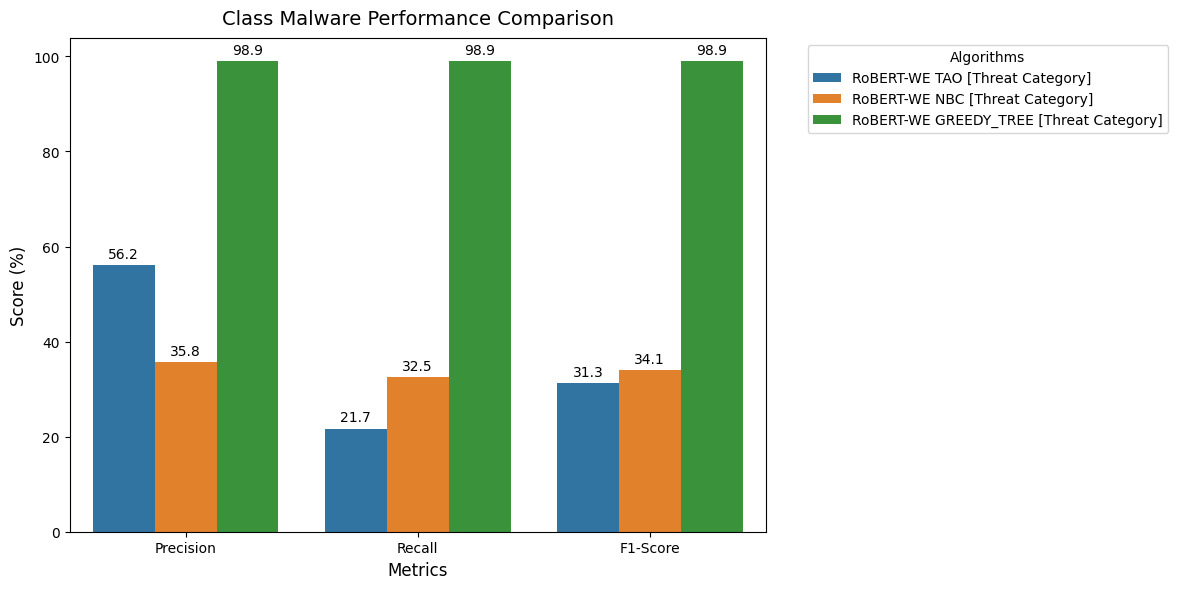

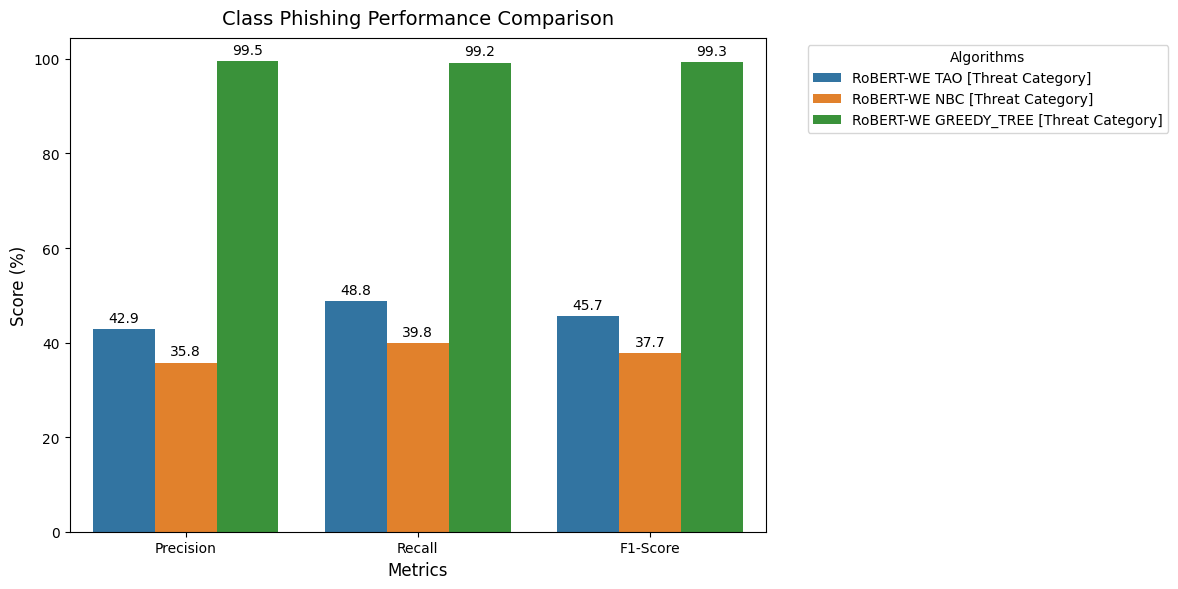

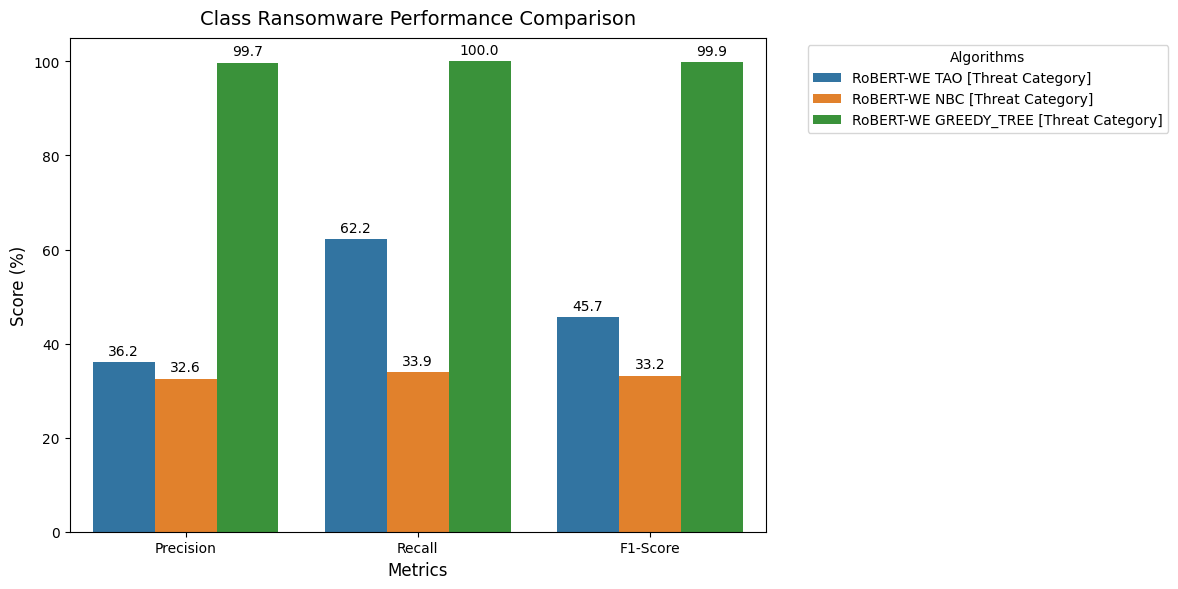

In [26]:
graph_plotter_lb1 = GraphPlotter(metrics_calculator_lb1.metrics_df, metrics_calculator_lb1.class_performance_dfs)
graph_plotter_lb1.plot_all()

In [27]:
# Work-Life Balance
melted_df_lb1 = metrics_calculator_lb1.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb1 = melted_df_lb1.round(3)
melted_df_lb1

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,RoBERT-WE TAO [Threat Category],43.659,47.661,43.657,42.611
1,RoBERT-WE NBC [Threat Category],34.941,34.971,34.938,34.896
2,RoBERT-WE GREEDY_TREE [Threat Category],99.472,99.471,99.472,99.471


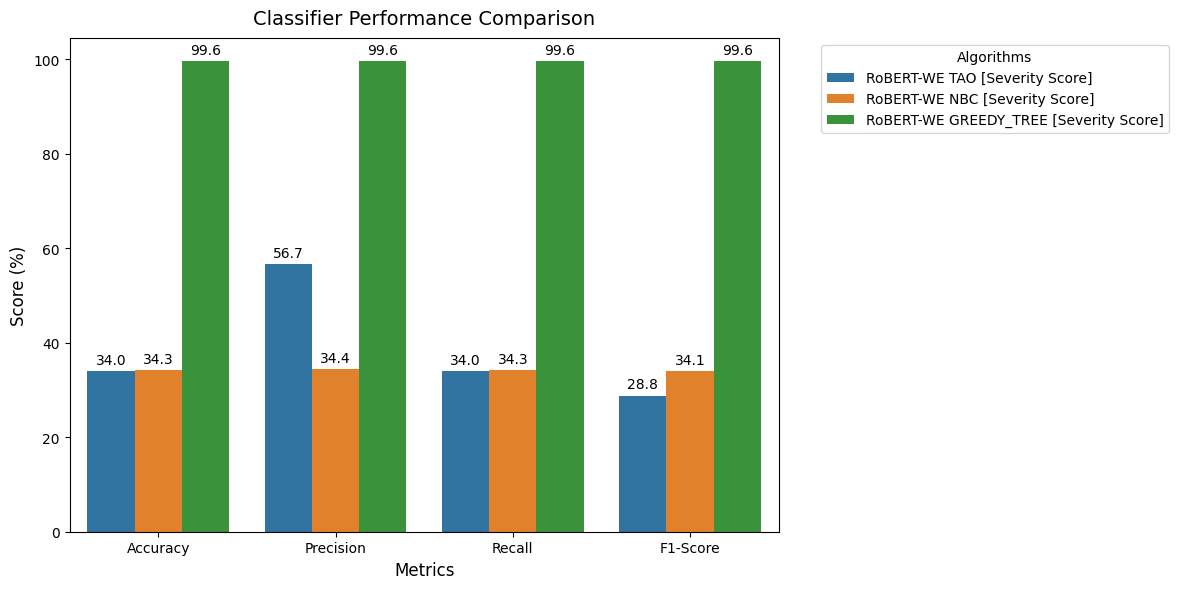

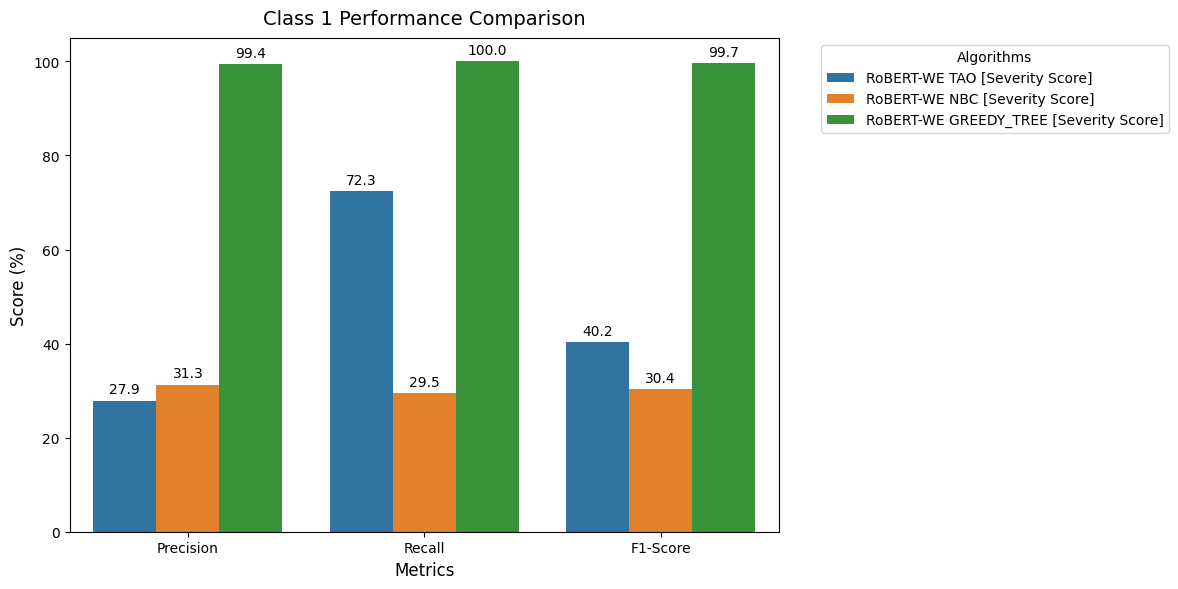

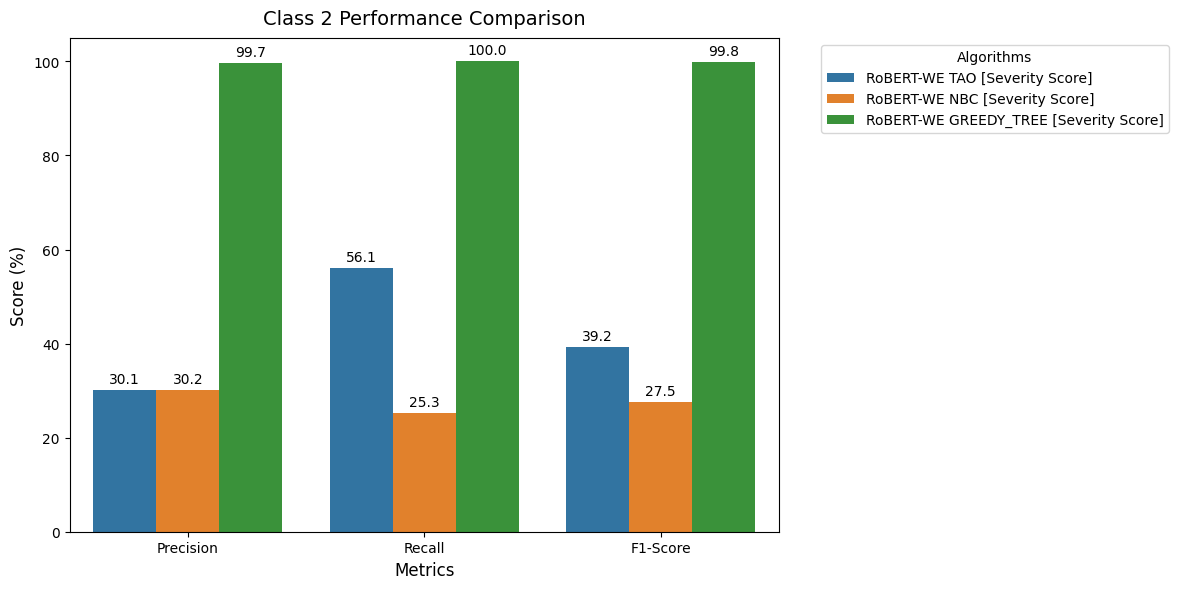

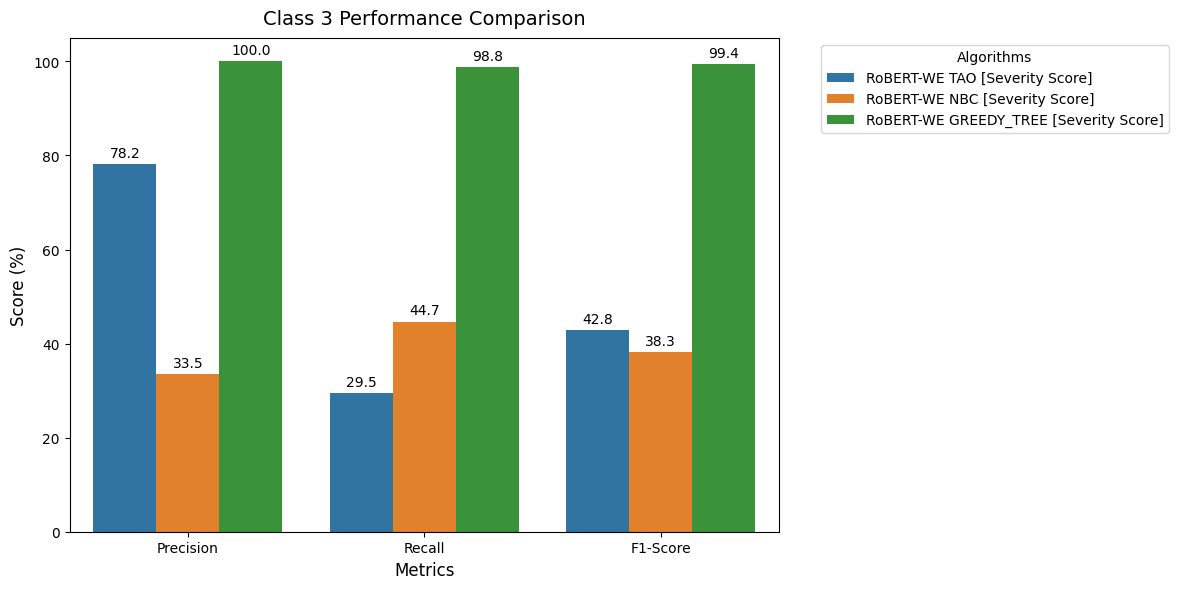

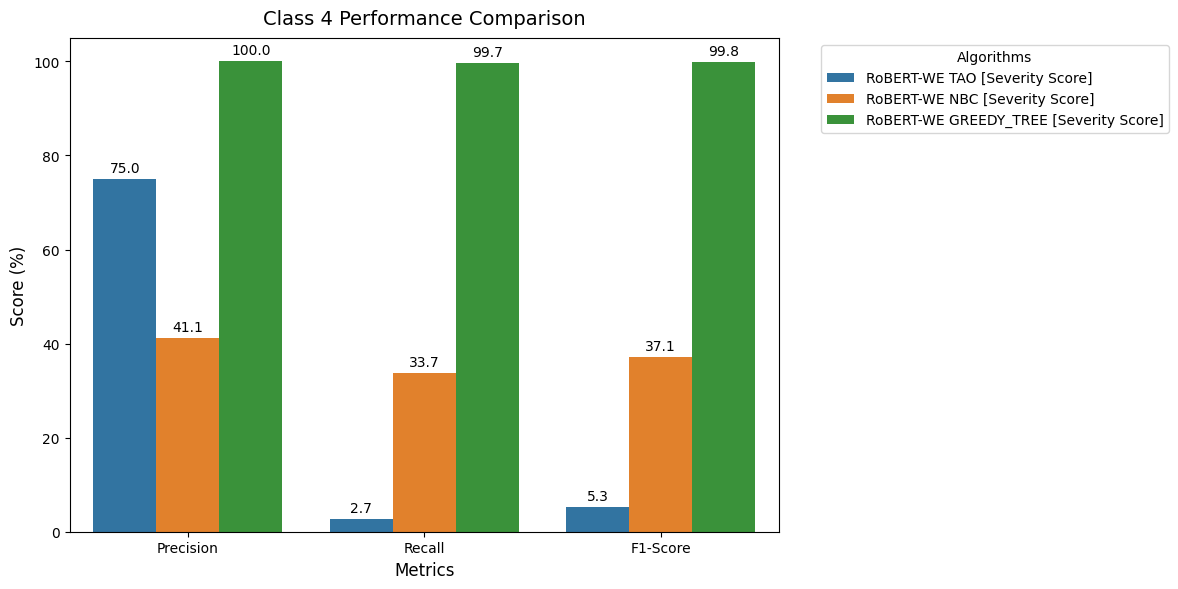

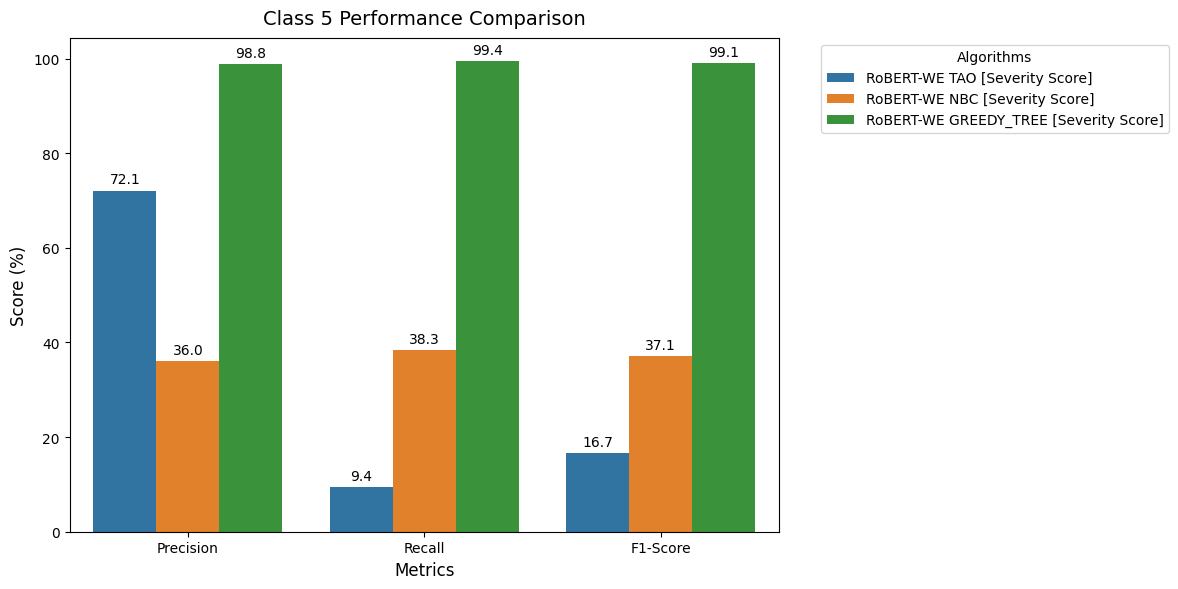

In [28]:
graph_plotter_lb2 = GraphPlotter(metrics_calculator_lb2.metrics_df, metrics_calculator_lb2.class_performance_dfs)
graph_plotter_lb2.plot_all()

In [22]:
# Work-Life Balance
melted_df_lb2 = metrics_calculator_lb2.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb2 = melted_df_lb2.round(3)
melted_df_lb2

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,RoBERT-WE TAO [Severity Score],34.002,56.660,34.016,28.840
1,RoBERT-WE KNN [Severity Score],95.499,95.516,95.498,95.501
2,RoBERT-WE NBC [Severity Score],34.307,34.414,34.301,34.069
3,RoBERT-WE GREEDY_TREE [Severity Score],99.574,99.577,99.574,99.574


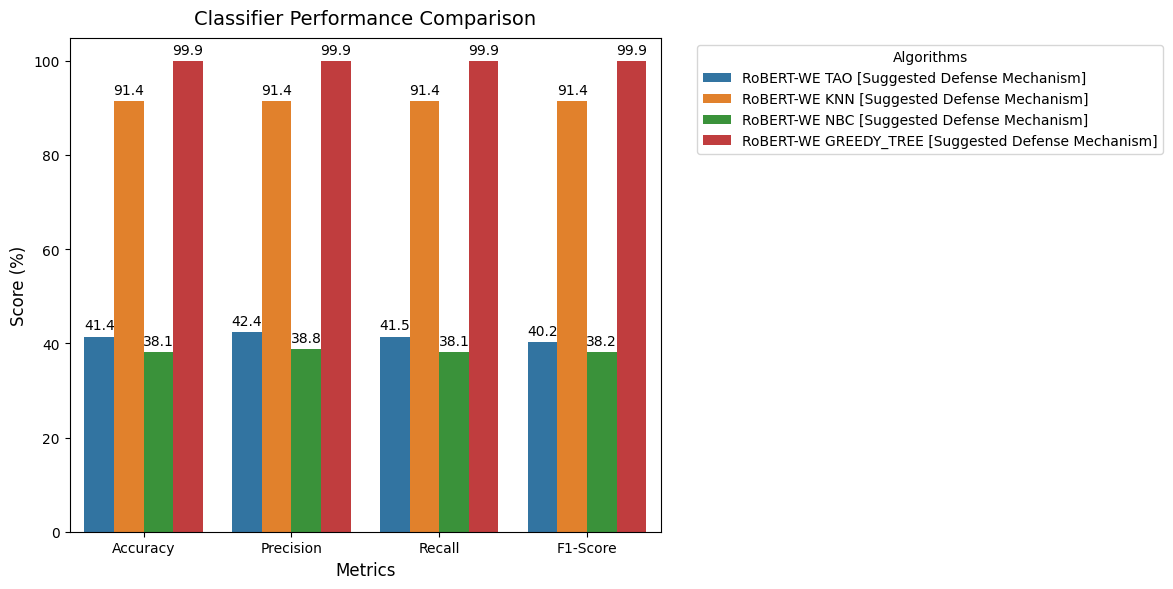

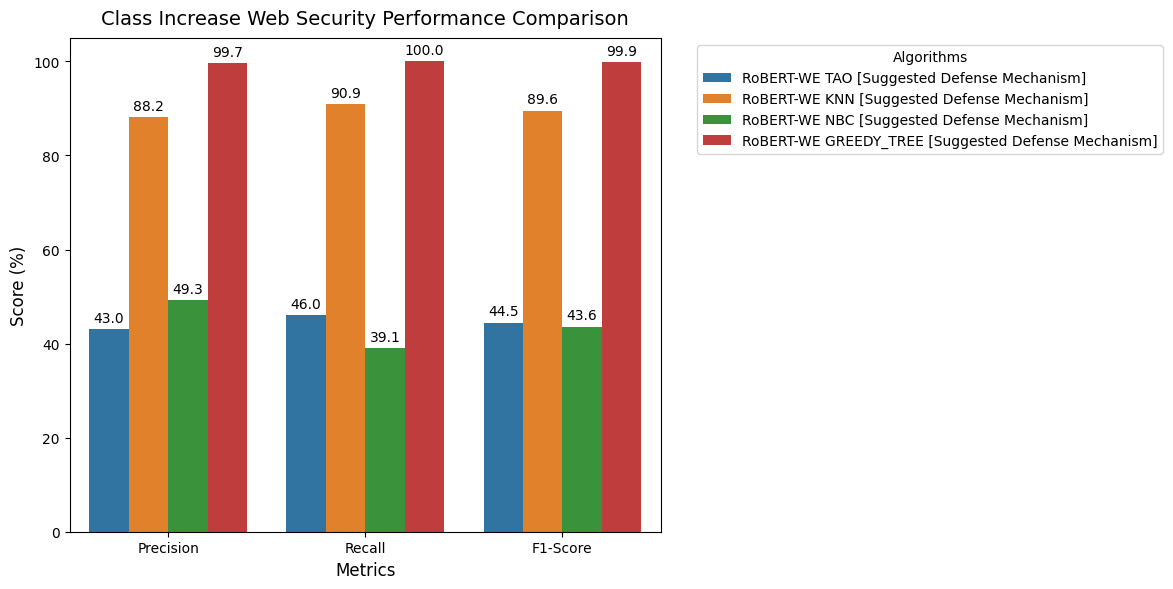

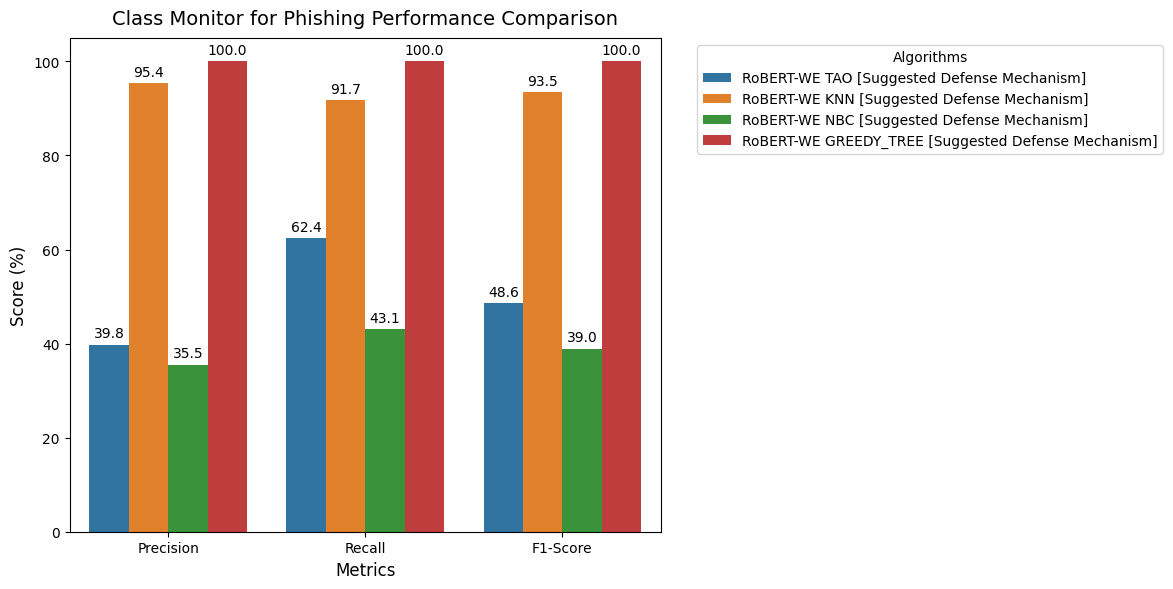

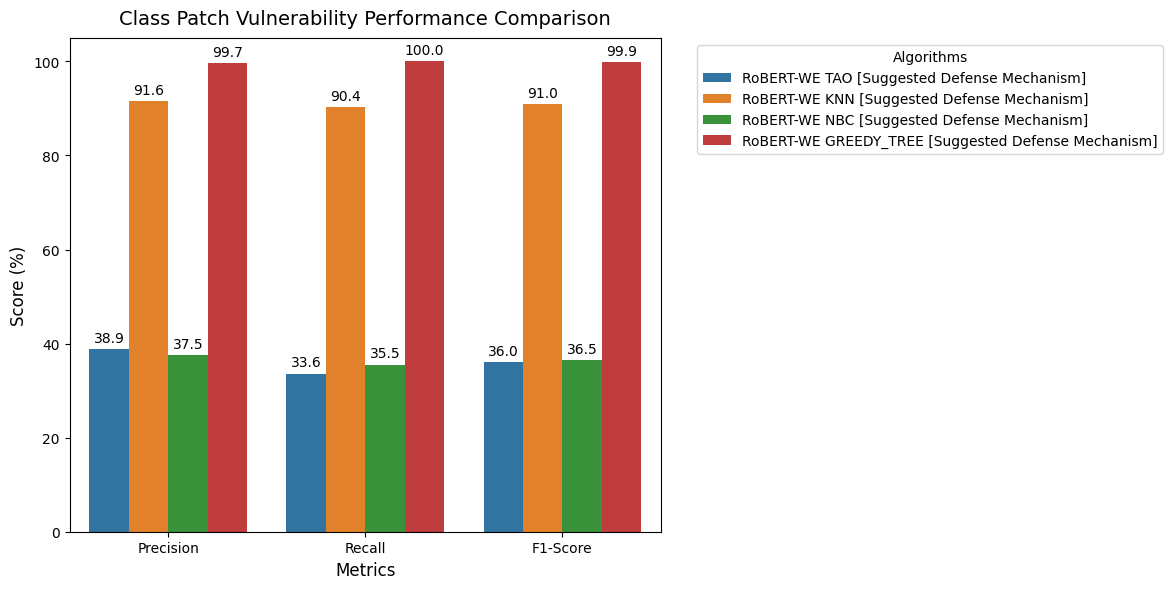

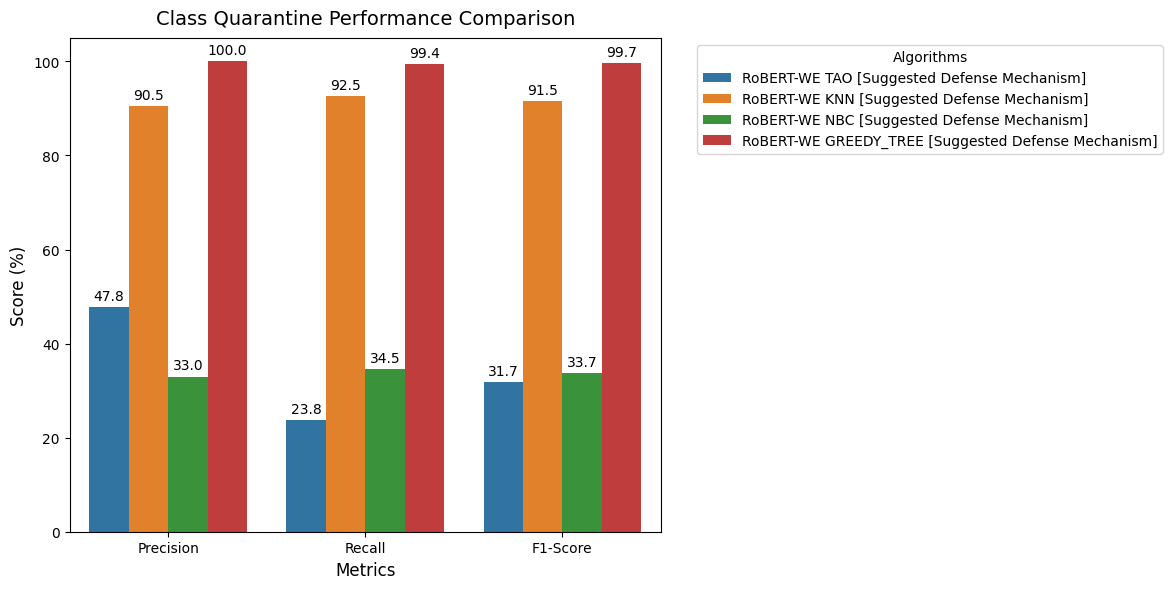

In [23]:
graph_plotter_lb3 = GraphPlotter(metrics_calculator_lb3.metrics_df, metrics_calculator_lb3.class_performance_dfs)
graph_plotter_lb3.plot_all()

In [29]:
# Work-Life Balance
melted_df_lb3 = metrics_calculator_lb3.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb3 = melted_df_lb3.round(3)
melted_df_lb3

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,RoBERT-WE TAO [Suggested Defense Mechanism],41.448,42.365,41.451,40.213
1,RoBERT-WE NBC [Suggested Defense Mechanism],38.069,38.831,38.070,38.202
2,RoBERT-WE GREEDY_TREE [Suggested Defense Mecha...,99.862,99.863,99.862,99.862


In [30]:
test_path=r"Dataset/Test_Less.csv"

In [31]:
df_test1= upload_dataset(test_path)
df_test1
# Initialize result DataFrame
df_result = df_test1.copy()


In [32]:
df_test,_ = preprocess_data(df_test1)

Preprocessing data (no saving)


In [33]:
features_test = feature_extraction(df_test,method='DeBERTa_word_embeddings',is_train=False)

[INFO] Feature extraction method: DeBERTa_word_embeddings, Train mode: False
[INFO] Performing DeBERTa feature extraction for testing...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Extracting DeBERTa embeddings: 100%|█████████████████████████████████████████████████████| 2/2 [00:15<00:00,  7.90s/it]


In [29]:
# Loop over each target
for target in ['Threat Category', 'Severity Score', 'Suggested Defense Mechanism']:
    # Predict using the model
    key_name = f"{target}_GREEDY_TREE"  
    y_pred = Proposed_Model[key_name].predict(features_test)

    le = label_encoders_original[target]
    y_pred_int = y_pred.astype(int)  
    mapped_labels = le.inverse_transform(y_pred_int)

    df_result[f'Predicted_{target}'] = mapped_labels

# Final output
df_result


,IOCs (Indicators of Compromise),Threat Actor,Attack Vector,Geographical Location,Sentiment in Forums,Risk Level Prediction,Cleaned Threat Description,Keyword Extraction,Named Entities (NER),Topic Modeling Labels,Word Count,Predicted_Threat Category,Predicted_Severity Score,Predicted_Suggested Defense Mechanism
0,['123.456.78.9'],APT-28,Email,North Korea,0.99,4,ransomware attack through network vulnerability,"['malware', 'email', 'attachment']","['CompanyY', 'Malware']",Malware,47,DDoS,5,Increase Web Security
1,"['10.0.0.2', 'infected.exe']",Lazarus Group,Network,USA,0.97,4,phishing email with malicious link,"['DDoS', 'website', 'attack']","['Unknown', 'Phishing Service']",Phishing,31,Malware,1,Quarantine
2,"['malwarehash123', 'trojan.com']",APT-28,Email,North Korea,0.87,2,ransomware attack through network vulnerability,"['phishing', 'corporate', 'scam']","['CompanyY', 'Malware']",Malware,24,Phishing,3,Quarantine
3,"['192.168.1.1', 'malicious.com']",Lazarus Group,Web,Global,0.64,1,phishing email with malicious link,"['DDoS', 'website', 'attack']","['CompanyY', 'Malware']",DDoS,46,DDoS,2,Quarantine
4,"['malwarehash123', 'trojan.com']",Unknown,Email,Germany,0.57,1,phishing scam targeting corporate accounts,"['DDoS', 'website', 'attack']","['Lazarus Group', 'Network Device']",DDoS,24,DDoS,1,Patch Vulnerability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,['123.456.78.9'],APT-28,Email,USA,0.52,2,malware detected in email attachment,"['malware', 'email', 'attachment']","['Unknown', 'Phishing Service']",Ransomware,24,Phishing,4,Patch Vulnerability
60,['123.456.78.9'],Lazarus Group,Network,USA,0.82,4,distributed denial of service attack on public...,"['DDoS', 'website', 'attack']","['Unknown', 'Phishing Service']",Phishing,38,DDoS,4,Patch Vulnerability
61,"['malicious.net', 'spam.exe']",Anonymous,Email,Russia,0.61,2,malware detected in email attachment,"['phishing', 'corporate', 'scam']","['Unknown', 'Phishing Service']",Phishing,12,DDoS,2,Patch Vulnerability
62,"['malicious.net', 'spam.exe']",Lazarus Group,Web,Russia,0.84,3,phishing scam targeting corporate accounts,"['phishing', 'corporate', 'scam']","['CompanyY', 'Malware']",Malware,20,Phishing,2,Patch Vulnerability
